# Analysis Notebook

# Setup

In [ ]:

packages <- c("MuMIn","lunar", "glmmTMB", "DHARMa", "broom.mixed", "emmeans", "lmerTest", "lme4", "patchwork", "devtools", "tidyverse", "dplyr","writexl","readxl")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))
  }
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)
}

invisible(lapply(packages, quiet_load))


Registered S3 methods overwritten by 'broom':
  method        from 
  nobs.fitdistr MuMIn
  nobs.multinom MuMIn

package 'cli' successfully unpacked and MD5 sums checked
package 'rlang' successfully unpacked and MD5 sums checked
package 'devtools' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
    C:\Users\or81\AppData\Local\Temp\Rtmp4kPpXJ\downloaded_packages

New names:
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`

New names:
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`

# CPUE and BPUE derivation

## Length–weight model and predicted weights

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

(`geom_point()`).

(`geom_point()`).

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

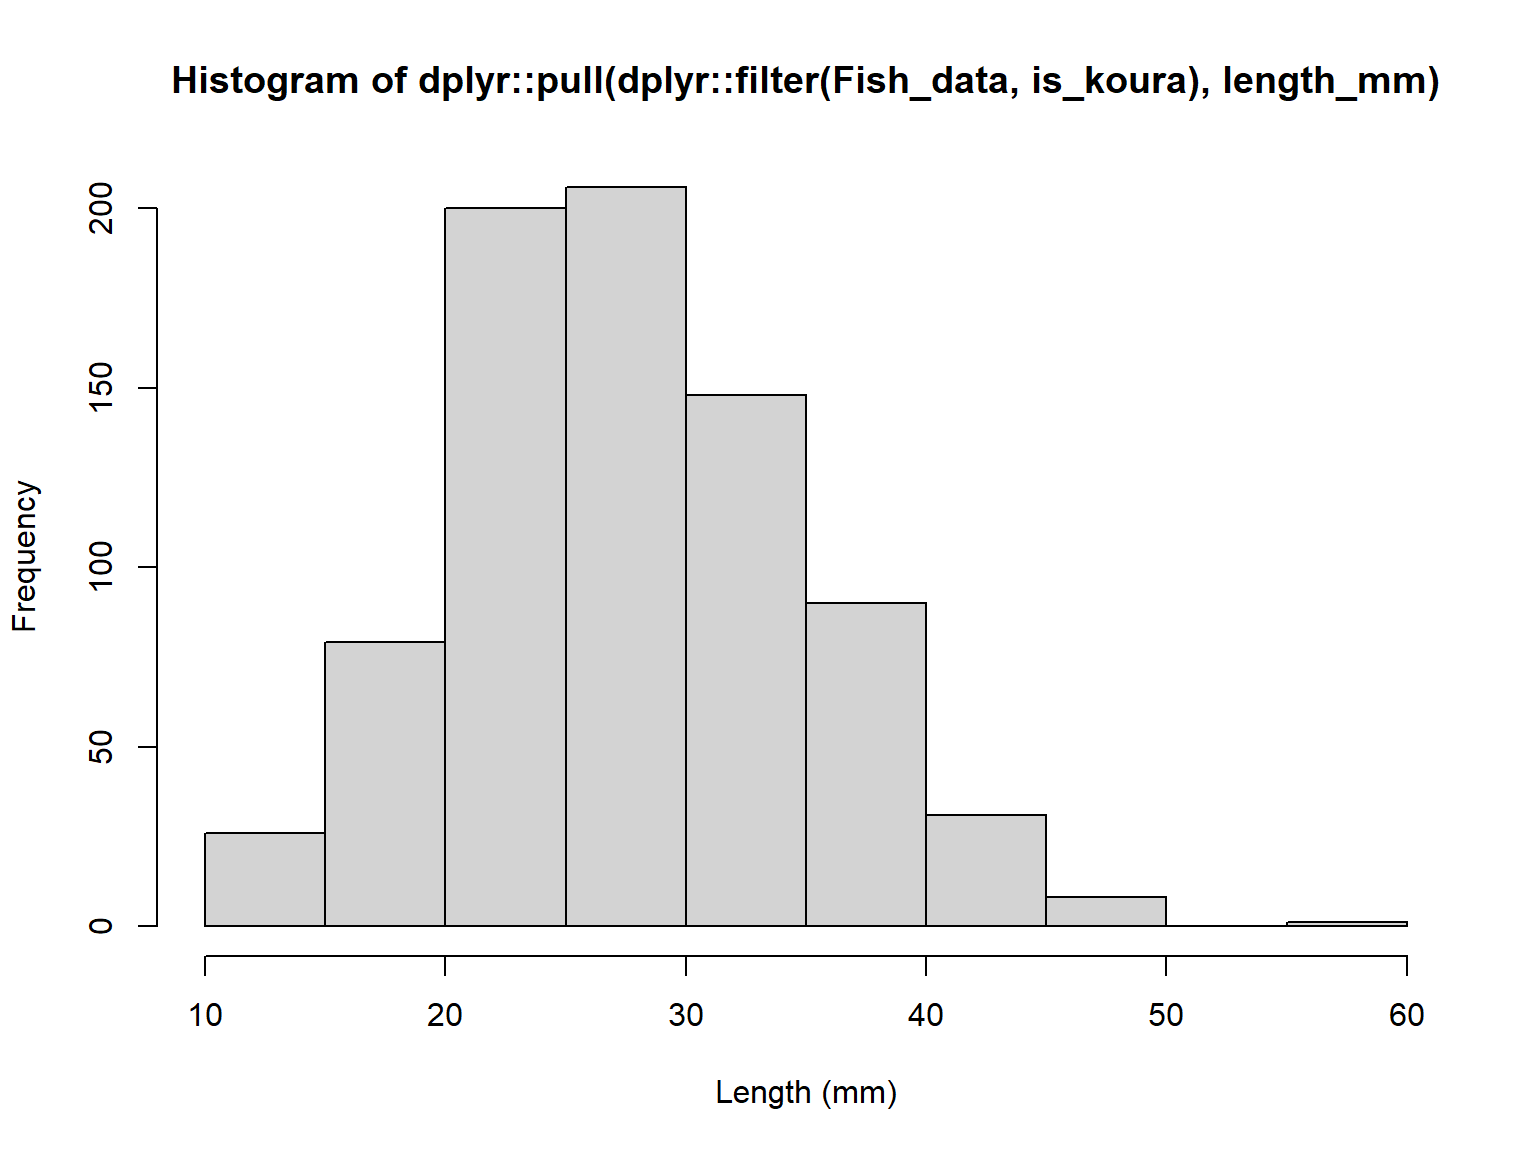

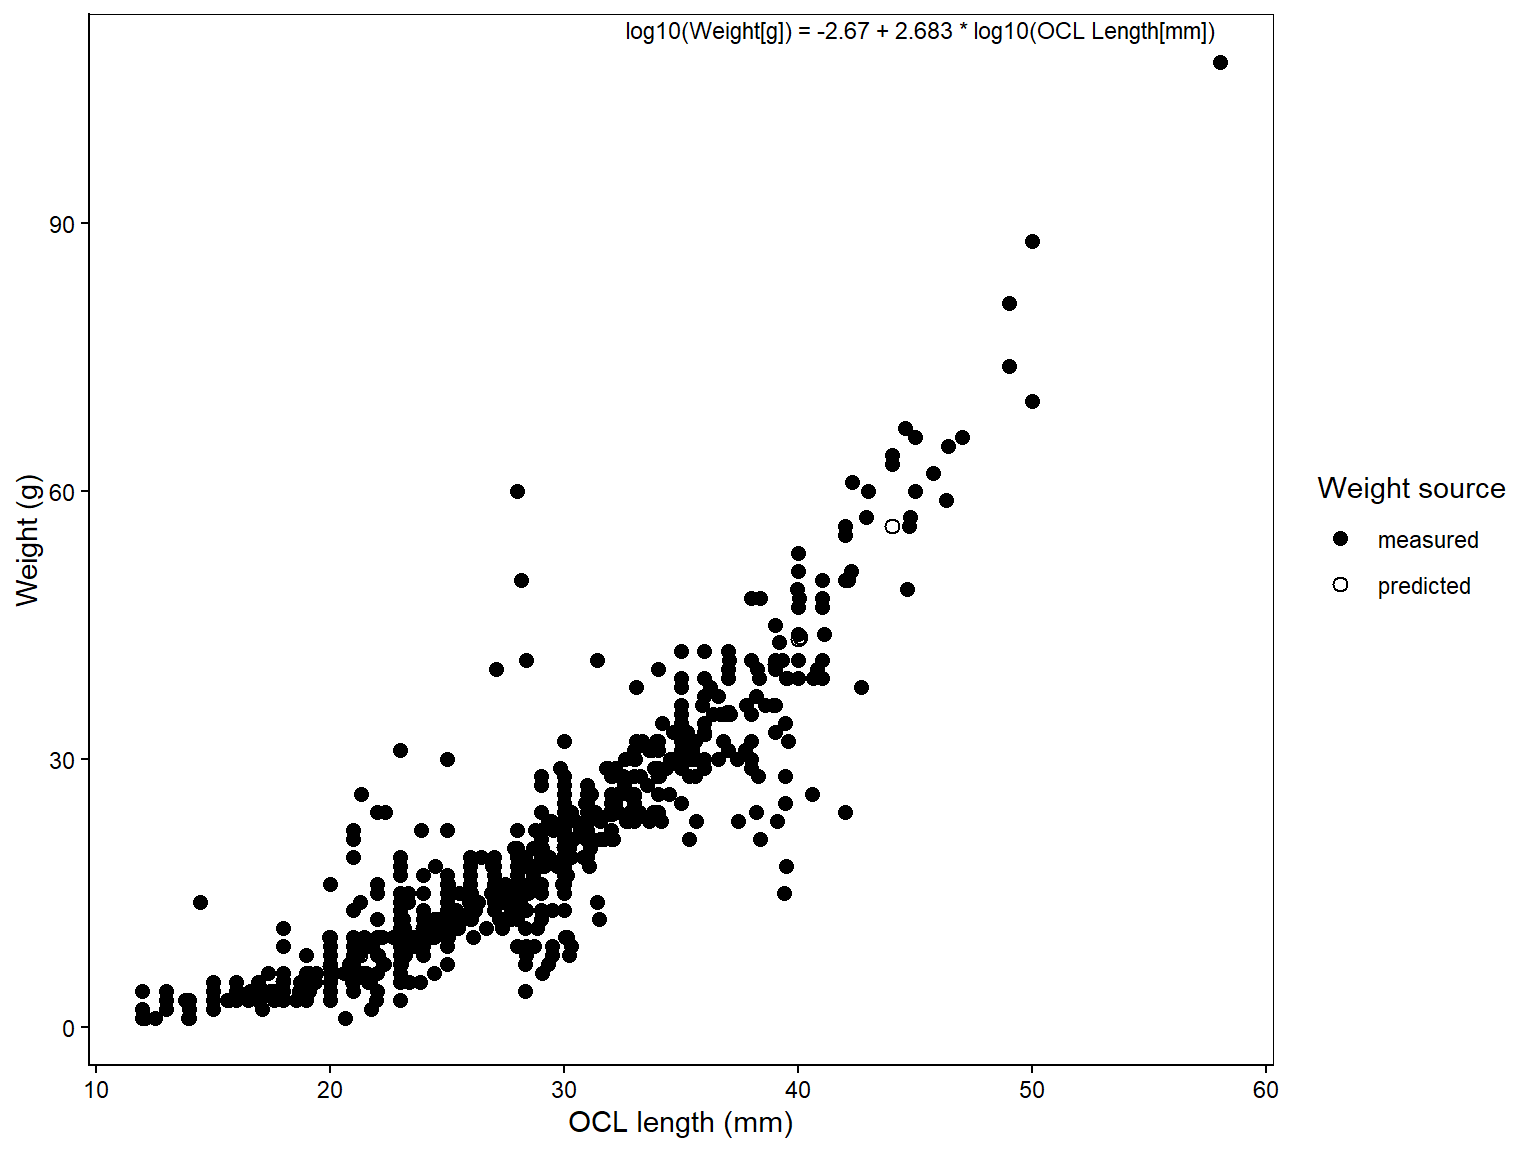

In [ ]:

# use size of koura to fill missing weights.
lw_model <- lm(log10(weight_g) ~ log10(length_mm), data = Fish_data, subset = species_name == "Freshwater_crayfish", na.action = na.exclude)

# extract the residual variance
sigma_log10 <- sigma(lw_model)
c <- 10^(0.5 * sigma_log10^2)

Fish_data <- Fish_data |>
  mutate(is_koura = species_name == "Freshwater_crayfish",
    Predicted_weight = case_when( !is.na(weight_g) ~ weight_g,
      is_koura ~ {pred_log <- predict(lw_model, newdata = pick(everything()))
        10^(pred_log) * c}, TRUE ~ NA_real_ ),
    Weight_source = case_when(is_koura & !is.na(weight_g) ~ "measured",
      is_koura & is.na(weight_g) ~ "predicted",TRUE ~ NA_character_))

count_df <- Fish_data |>
  dplyr::filter(is_koura, !is.na(Weight_source)) |>
  dplyr::count(Weight_source, name = "n")

measured_n  <- count_df$n[count_df$Weight_source == "measured"]
predicted_n <- count_df$n[count_df$Weight_source == "predicted"]

total_koura <- Fish_data |>
  dplyr::filter(is_koura) |>
  nrow()

hist(Fish_data |> dplyr::filter(is_koura) |> dplyr::pull(length_mm), xlab = "Length (mm)")

# Extract model coefficients
a <- coef(lw_model)[1]
b <- coef(lw_model)[2]

# Create formula text for the plot
formula_text <- paste0( "log10(Weight[g]) = ", round(a, 3), " + ", round(b, 3), " * log10(OCL Length[mm])")

# Plot with formula added
length_weight_plot <- ggplot(
Fish_data |> dplyr::filter(is_koura),
aes(x = length_mm, y = Predicted_weight, shape = Weight_source)) +
geom_point(size = 2.2, colour = "black", stroke = 0.6) +
scale_shape_manual(values = c("measured" = 16, "predicted" = 1)) +
labs(x = "OCL length (mm)", y = "Weight (g)", shape = "Weight source") +
annotate("text", x = Inf, y = Inf, label = formula_text, hjust = 1.1, vjust = 1.3, size = 3) 

ggsave(file.path(out_dir, "fig-length-weight.png"),length_weight_plot,width = 8, height = 5, dpi = 300)


## Build CPUE and BPUE tables

In [ ]:

CPUE_BPUE_legacy <- Fish_data %>%
  filter(!is.na(species)) %>%
  group_by(monitoring_id, species, net_type) %>%
  dplyr::reframe(
    Total_Individuals = sum(amount, na.rm = TRUE),
    Total_Weight      = sum(weight_g, na.rm = TRUE),
    Total_Effort      = dplyr::first(amount_nets),
    CPUE              = Total_Individuals / Total_Effort,
    BPUE              = Total_Weight      / Total_Effort,
    Mean_Length       = mean(length_mm, na.rm = TRUE),
    Min_Length        = ifelse(all(is.na(length_mm)), NA, min(length_mm, na.rm = TRUE)),
    Max_Length        = ifelse(all(is.na(length_mm)), NA, max(length_mm, na.rm = TRUE)),
    Mean_Weight       = mean(weight_g, na.rm = TRUE),
    Min_Weight        = ifelse(all(is.na(weight_g)), NA, min(weight_g, na.rm = TRUE)),
    Max_Weight        = ifelse(all(is.na(weight_g)), NA, max(weight_g, na.rm = TRUE))
  )

CPUE_BPUE_weighted <- CPUE_BPUE_legacy %>%
  group_by(monitoring_id, species) %>%
  summarise(
    Total_Individuals       = sum(Total_Individuals, na.rm = TRUE),
    Total_Weight            = sum(Total_Weight,      na.rm = TRUE),
    Weighted_CPUE_numerator = sum(CPUE * Total_Effort,  na.rm = TRUE),
    Weighted_BPUE_numerator = sum(BPUE * Total_Effort,  na.rm = TRUE),
    Total_Effort_sum        = sum(Total_Effort,         na.rm = TRUE),
    Mean_Length             = mean(Mean_Length, na.rm = TRUE),
    Min_Length              = ifelse(all(is.na(Min_Length)), NA, min(Min_Length, na.rm = TRUE)),
    Max_Length              = ifelse(all(is.na(Max_Length)), NA, max(Max_Length, na.rm = TRUE)),
    Mean_Weight             = mean(Mean_Weight, na.rm = TRUE),
    Min_Weight              = ifelse(all(is.na(Min_Weight)), NA, min(Min_Weight, na.rm = TRUE)),
    Max_Weight              = ifelse(all(is.na(Max_Weight)), NA, max(Max_Weight, na.rm = TRUE)),
    .groups = "drop") %>%
  ungroup() %>%
  mutate(Total_Effort_sum = ifelse(monitoring_id %in% c("16_0", "10_1", "3_2", "16_2"), 3, 4),
    Weighted_CPUE    = Weighted_CPUE_numerator / Total_Effort_sum,
    Weighted_BPUE    = Weighted_BPUE_numerator / Total_Effort_sum)

species_presence_absence <- Fish_data %>%
  filter(!is.na(species)) %>%
  distinct(monitoring_id, species) %>%
  mutate(presence = 1) %>%
  pivot_wider(
    names_from  = species,
    values_from = presence,
    values_fill = list(presence = 0),
    names_prefix = "Presence_") %>%
  mutate(Predator_Fish_Presence = pmax(Presence_Trout, Presence_Eel, Presence_Catfish))

CPUE_BPUE_weighted_summary <- CPUE_BPUE_weighted %>%
  pivot_wider(
    names_from  = species,
    values_from = c(
      Total_Individuals, Weighted_CPUE, Weighted_BPUE, Total_Weight,
      Mean_Length, Mean_Weight, Weighted_CPUE_numerator, Weighted_BPUE_numerator,
      Total_Effort_sum, Min_Length, Max_Length, Min_Weight, Max_Weight),
    names_sep   = "_", values_fill = list(Total_Individuals = 0, Weighted_CPUE = 0, Weighted_BPUE = 0)) %>%
  mutate(
    Richness  = rowSums(dplyr::select(., starts_with("Total_Individuals_")) > 0),
    Abundance = rowSums(dplyr::select(., starts_with("Total_Individuals_") & !ends_with(c("_Bullies", "_Common_smelt")))))


# Combined all datasets

In [ ]:

unit_metadata <- dplyr::bind_rows(Monitoring_data %>%
    dplyr::select(parameter, unit), Chemical_data %>%
    dplyr::select(parameter, unit)) %>%
  dplyr::distinct() %>%
  dplyr::rename(Variable = parameter, Unit = unit)

Monitoring_summary <- Monitoring_data %>%
  dplyr::select(-group, -notes, -unit, -monitoring_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Riparian_vegetation, Vegetation_nearby, Overhanging_trees, Erosion, Structure, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter, Wood_cover ), ~ as.numeric(.)))

Chemical_summary <- Chemical_data %>%
  dplyr::select(-group, -notes, -unit, -site_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), ~ as.numeric(.)))

Weed_summary <- Weed_data %>%
  group_by(monitoring_id, weed_type, native_status) %>%
  summarise(Total_Cover = sum(percentage_cover, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from  = c(weed_type, native_status), values_from = Total_Cover, values_fill = 0) %>% 
  dplyr::select(monitoring_id, Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Turf_Native)

Stone_pile_summary <- Stone_pile_data %>%
  select(-unit, -notes, -site_id)%>%
  pivot_wider(names_from = c(parameter, stone_pile_id), values_from = value, names_sep = ".")

Macroinvertebrates_sum <- Macroinvertebrates %>%
  group_by(monitoring_id, species) %>%
  summarise(Total_amount = sum(amount, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = c(species), values_from = Total_amount, values_fill = 0) %>%
  mutate(Invertebrates_Richness  = rowSums(dplyr::select(., -monitoring_id) > 0),
    Invertebrates_Abundance = rowSums(dplyr::select(., -monitoring_id)))

Combined_data <- Site_info %>%
  left_join(Monitoring_summary, by = "site_id") %>%
  left_join(Chemical_summary, by = c("monitoring_id")) %>%
  left_join(Weed_summary, by = c("monitoring_id")) %>%
  left_join(Stone_pile_summary, by = c("monitoring_id")) %>%
  left_join(CPUE_BPUE_weighted_summary, by = "monitoring_id") %>%
  left_join(species_presence_absence, by = "monitoring_id") %>%
  left_join(Macroinvertebrates_sum, by = "monitoring_id")

Combined_data <- Combined_data %>%
  dplyr::mutate(Presence_rocks = dplyr::if_else(Cobble > 1 | Boulders > 1, 1, 0),
    Period = factor(dplyr::if_else(monitoring == 0, "Before", "After"),levels = c("Before", "After")),
    Date  = as.Date(date_time),
    Time  = format(date_time, "%H:%M:%S"),
    Year  = lubridate::year(date_time),
    Month = lubridate::month(date_time, label = TRUE),
    Day   = lubridate::day(date_time),
    Season = dplyr::case_when(
      Month %in% c("Dec", "Jan", "Feb") ~ "Summer",
      Month %in% c("Mar", "Apr", "May") ~ "Autumn",
      Month %in% c("Jun", "Jul", "Aug") ~ "Winter",
      Month %in% c("Sep", "Oct", "Nov") ~ "Spring",
      TRUE ~ NA_character_),
    Date_Time_Numeric = as.numeric(date_time),
    Monitoring_label = dplyr::case_when(
      monitoring == 0 ~ "0 Pre/Summer",
      monitoring == 1 ~ "1 Autumn",
      monitoring == 2 ~ "2 Winter",
      monitoring == 3 ~ "3 Spring",
      monitoring == 4 ~ "4 Summer",
      monitoring == 5 ~ "5 Autumn",
      monitoring == 6 ~ "6 Winter",
      TRUE ~ as.character(monitoring)
    ) %>% as.factor(), site_id = as.factor(site_id)) %>%
  dplyr::mutate(Depth_5m  = suppressWarnings(as.numeric(Distance_5m)), Depth_20m = suppressWarnings(as.numeric(Distance_20m)),
    Slope_0_5m  = Depth_5m  / 5, Slope_0_20m = Depth_20m / 20)
        

habitat_classification <- Combined_data %>%
  dplyr::select(site_id, DHT, lake,
                Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover) %>%
  pivot_longer(cols = c(Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                  Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover),
    names_to  = "Type", values_to = "Percentage") %>%
  group_by(site_id) %>%
  summarise(Rocky_Percentage  = sum(Percentage[Type %in% c("Bedrock", "Boulders", "Cobble")], na.rm = TRUE),
    Sand_Percentage     = sum(Percentage[Type == "Sand"], na.rm = TRUE),
    Mud_Percentage      = sum(Percentage[Type %in% c("Mud", "Organic_matter")], na.rm = TRUE),
    Emergent_Percentage = sum(Percentage[Type %in% c("Emergent_Native")], na.rm = TRUE),
    Substrate_index = sum(
      0.08 * Percentage[Type == "Bedrock"] +
      0.07 * Percentage[Type == "Boulders"] +
      0.06 * Percentage[Type == "Cobble"] +
      0.04 * Percentage[Type == "Gravel"] +
      0.03 * Percentage[Type == "Sand"] +
      0.02 * Percentage[Type == "Organic_matter"] +
      0.01 * Percentage[Type == "Mud"],
      na.rm = TRUE),.groups = "drop") %>%
  mutate(Habitat_Type = case_when(
      Rocky_Percentage    > 25 ~ "Rocky",
      Emergent_Percentage > 25 ~ "Emergent Macrophyte",
      Sand_Percentage   >= Mud_Percentage ~ "Sandy",
      TRUE ~ "Muddy")) %>%
  dplyr::select(site_id, Habitat_Type, Substrate_index)

Combined_data <- Combined_data %>%
  left_join(habitat_classification, by = c("site_id"))%>%
  dplyr::mutate(monitoring_int = as.integer(monitoring),
    pair_id = factor(ceiling(as.numeric(as.character(site_id)) / 2)),
    koura_present = as.integer(`Total_Individuals_Kōura` > 0))

Combined_data <- Combined_data %>%
  mutate(lunar_phase = lunar.phase(Date, name = FALSE),  # 0-2π radians
    lunar_illumination = (1 - cos(lunar.phase(Date))) / 2,  # 0=new, 1=full
    lunar_name = lunar.phase(Date, name = TRUE))     # "New", "Waxing", "Full", "Waning"

# Monitoring quality flag — based on known compromised events
compromised_ids <- c("6_1", "13_1", "14_1", "1_2", "2_2", "19_2", "20_2", "1_3", "2_3", "6_5")

Combined_data <- Combined_data %>%
  mutate(monitoring_quality = case_when(monitoring_id %in% compromised_ids ~ "compromised", is.na(`Total_Individuals_Kōura`) ~ "missing", TRUE  ~ "complete"))

writexl::write_xlsx(Combined_data, file.path(der_data_dir, "Combined_data.xlsx"))
write.csv(Combined_data, file.path(der_data_dir, "Combined_data.csv"), row.names = FALSE)
write.csv(habitat_classification, file.path(der_data_dir, "habitat_classification.csv"), row.names = FALSE)

all_data <- Combined_data


## Fish summary table

``` r

# Create a summary table for fish counts by site and monitoring
fish_summary <- all_data %>%
  select(site_id, Monitoring_label,
         Total_Individuals_Kōura,
         Total_Individuals_Bullies,
         Total_Individuals_Common_smelt,
         Total_Individuals_Goldfish,
         Total_Individuals_Eel,
         Total_Individuals_Kōaro,
         Total_Individuals_Catfish,
         Total_Individuals_Trout,
         Total_Individuals_Mosquitofish) %>%
  pivot_longer(
    cols = c(Total_Individuals_Kōura, Total_Individuals_Bullies,
             Total_Individuals_Common_smelt, Total_Individuals_Goldfish,
             Total_Individuals_Eel, Total_Individuals_Kōaro,
             Total_Individuals_Catfish, Total_Individuals_Trout,
             Total_Individuals_Mosquitofish),
    names_to = "Species",
    values_to = "Count") %>%
  group_by(site_id, Monitoring_label, Species) %>%
  summarise(Total_Count = sum(Count, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(
    names_from = Species,
    values_from = Total_Count) %>%
  arrange(site_id, Monitoring_label, Total_Individuals_Kōura, Total_Individuals_Bullies, Total_Individuals_Common_smelt,    Total_Individuals_Goldfish, Total_Individuals_Eel,Total_Individuals_Kōaro,Total_Individuals_Catfish,Total_Individuals_Trout,Total_Individuals_Mosquitofish)


write.csv(fish_summary, file.path(der_data_dir, "tbl-fish-summary.csv"), row.names = FALSE)

fish_summary
```

    # A tibble: 120 × 11
       site_id Monitoring_label Total_Individuals_Bullies Total_Individuals_Catfish
       <fct>   <fct>                                <dbl>                     <dbl>
     1 1       0 Pre/Summer                             2                         0
     2 1       1 Autumn                                15                         0
     3 1       2 Winter                                 1                         0
     4 1       3 Spring                                 0                         0
     5 1       4 Summer                                 3                         0
     6 1       5 Autumn                                20                         0
     7 2       0 Pre/Summer                             2                         0
     8 2       1 Autumn                                17                         0
     9 2       2 Winter                                 5                         0
    10 2       3 Spring                                 0                         0
    # ℹ 110 more rows
    # ℹ 7 more variables: Total_Individuals_Common_smelt <dbl>,
    #   Total_Individuals_Eel <dbl>, Total_Individuals_Goldfish <dbl>,
    #   Total_Individuals_Kōaro <dbl>, Total_Individuals_Kōura <dbl>,
    #   Total_Individuals_Mosquitofish <dbl>, Total_Individuals_Trout <dbl>

# Environmental and fish summaries (table)

In [ ]:

group_var <- "site_id" # or monitoring_id

var_order_exact <- c("Substrate index","Riparian vegetation","Overhanging trees","Wood cover","Emergent vegetation","Submerged vegetation", "Temperature","Dissolved oxygen","Specific conductivity","pH","Presence Kōura", "Presence Catfish","Presence Eel","Presence Goldfish","Presence Common smelt", "Presence Kōaro","Presence Trout")

ci95 <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  if (n < 2) return(c(NA_real_, NA_real_))
  se <- stats::sd(x) / sqrt(n)
  tcrit <- stats::qt(0.975, df = n - 1)
  m <- mean(x)
  c(m - tcrit * se, m + tcrit * se)
}

site_lookup <- all_data %>%
  dplyr::select(site_id, site) %>%
  dplyr::distinct() %>%
  dplyr::mutate(site_id   = as.character(site_id), site = as.character(site))

unit_map <- dplyr::tibble(Variable = c("Substrate_index","Riparian_vegetation","Overhanging_trees","Wood_cover", "Temperature","DO_mgl","Specific_conductivity","pH"))

Env_data <- all_data %>%
  dplyr::mutate(
    Emergent_vegetation  = Emergent_Native + Emergent_Non_Native,
    Submerged_vegetation = Submerged_Non_Native) %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Substrate_index, Riparian_vegetation, Overhanging_trees, Wood_cover,
    Emergent_vegetation, Submerged_vegetation,
    Temperature, DO_mgl, Specific_conductivity, pH ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Value")

Env_summary_by_group <- Env_data %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_all <- Env_data %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_table <- dplyr::bind_rows(Env_summary_by_group, Env_summary_all)

# ---- Fish presence data (long) ----
Fish_data_long <- all_data %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Presence_Kōura, Presence_Catfish, Presence_Eel, Presence_Goldfish, Presence_Common_smelt, Presence_Kōaro, Presence_Trout ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Presence")

Fish_summary_by_group <- Fish_data_long %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_all <- Fish_data_long %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_table <- dplyr::bind_rows(Fish_summary_by_group, Fish_summary_all)

# ---- Combine + attach units + pretty variable names + exact ordering ----
EnvBio_summary_table <- dplyr::bind_rows(Env_summary_table, Fish_summary_table) %>%
  dplyr::mutate(Group = as.character(Group)) %>%
  dplyr::left_join(
    site_lookup,
    by = c("Group" = "site_id")) %>%
  dplyr::left_join(unit_metadata, by = "Variable") %>%
  dplyr::mutate(
    Variable = dplyr::recode(
      Variable,
      Substrate_index       = "Substrate index",
      Riparian_vegetation   = "Riparian vegetation",
      Overhanging_trees     = "Overhanging trees",
      Wood_cover            = "Wood cover",
      Emergent_vegetation   = "Emergent vegetation",
      Submerged_vegetation  = "Submerged vegetation",
      Temperature           = "Temperature",
      DO_mgl                = "Dissolved oxygen",
      Specific_conductivity = "Specific conductivity",
      pH                    = "pH",
      Presence_Kōura        = "Presence Kōura",
      Presence_Catfish      = "Presence Catfish",
      Presence_Eel          = "Presence Eel",
      Presence_Goldfish     = "Presence Goldfish",
      Presence_Common_smelt = "Presence Common smelt",
      Presence_Kōaro        = "Presence Kōaro",
      Presence_Trout        = "Presence Trout" ),
    Unit = dplyr::coalesce(Unit, "")) %>%
  dplyr::mutate(
    Variable = factor(as.character(Variable), levels = var_order_exact),
    Group    = as.character(Group)) %>%
  dplyr::select(Group, Variable, Unit, n, Mean, Median, Min, Max, CI_low, CI_high) %>%
  dplyr::arrange(Variable, dplyr::desc(Group == "All sites"), Group)

# Optional: if you want Group sorted numerically when Group is ID
if (group_var == "site_id") {
  EnvBio_summary_table <- EnvBio_summary_table %>%
    dplyr::mutate(
      Group_num = suppressWarnings(as.numeric(Group))
    ) %>%
    dplyr::arrange(
      Variable,
      dplyr::desc(Group == "All sites"),
      Group_num,
      Group
    ) %>%
    dplyr::select(-Group_num)
}

write.csv(EnvBio_summary_table, file = file.path(out_dir, "EnvBio_summary_table.csv"), row.names = FALSE)

knitr::kable(EnvBio_summary_table, digits = 2, align = c("l","l","l","r","r","r","r","r","r","r"))


  ------------------------------------------------------------------------------------------------
  Group    Variable          Unit         n     Mean   Median      Min      Max   CI_low   CI_high
  -------- ----------------- -------- ----- -------- -------- -------- -------- -------- ---------
  All      Substrate index              120    26.47    28.20    14.40    39.60    25.06     27.89
  sites                                                                                  

  1        Substrate index                6    31.20    31.20    31.20    31.20    31.20     31.20

  2        Substrate index                6    26.40    26.40    26.40    26.40    26.40     26.40

  3        Substrate index                6    18.00    18.00    18.00    18.00    18.00     18.00

  4        Substrate index                6    18.00    18.00    18.00    18.00    18.00     18.00

  5        Substrate index                6    14.40    14.40    14.40    14.40    14.40     14.40

  6        Substrate index                6    18.00    18.00    18.00    18.00    18.00     18.00

  7        Substrate index                6    18.00    18.00    18.00    18.00    18.00     18.00

  8        Substrate index                6    18.00    18.00    18.00    18.00    18.00     18.00

  9        Substrate index                6    20.10    20.10    20.10    20.10    20.10     20.10

  10       Substrate index                6    30.00    30.00    30.00    30.00    30.00     30.00

  11       Substrate index                6    39.60    39.60    39.60    39.60    39.60     39.60

  12       Substrate index                6    37.20    37.20    37.20    37.20    37.20     37.20

  13       Substrate index                6    21.60    21.60    21.60    21.60    21.60     21.60

  14       Substrate index                6    21.00    21.00    21.00    21.00    21.00     21.00

  15       Substrate index                6    31.20    31.20    31.20    31.20    31.20     31.20

  16       Substrate index                6    31.20    31.20    31.20    31.20    31.20     31.20

  17       Substrate index                6    30.00    30.00    30.00    30.00    30.00     30.00

  18       Substrate index                6    37.20    37.20    37.20    37.20    37.20     37.20

  19       Substrate index                6    34.20    34.20    34.20    34.20    34.20     34.20

  20       Substrate index                6    34.20    34.20    34.20    34.20    34.20     34.20

  All      Riparian          \%         120    65.50   100.00     0.00   100.00    57.70     73.30
  sites    vegetation                                                                    

  1        Riparian          \%           6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  2        Riparian          \%           6    70.00    70.00    70.00    70.00    70.00     70.00
           vegetation                                                                    

  3        Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  4        Riparian          \%           6    80.00    80.00    80.00    80.00    80.00     80.00
           vegetation                                                                    

  5        Riparian          \%           6    10.00    10.00    10.00    10.00    10.00     10.00
           vegetation                                                                    

  6        Riparian          \%           6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  7        Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  8        Riparian          \%           6    30.00    30.00    30.00    30.00    30.00     30.00
           vegetation                                                                    

  9        Riparian          \%           6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  10       Riparian          \%           6    20.00    20.00    20.00    20.00    20.00     20.00
           vegetation                                                                    

  11       Riparian          \%           6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  12       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  13       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  14       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  15       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  16       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  17       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  18       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  19       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  20       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  All      Overhanging trees \%         120    45.75     7.50     0.00   100.00    36.83     54.67
  sites                                                                                  

  1        Overhanging trees \%           6    10.00    10.00    10.00    10.00    10.00     10.00

  2        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  3        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Overhanging trees \%           6     5.00     5.00     5.00     5.00     5.00      5.00

  5        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  7        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  8        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  10       Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  11       Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  12       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  13       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  14       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  15       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  16       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  17       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  18       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  19       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  20       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  All      Wood cover        \%         120     2.60     0.00     0.00    30.00     1.40      3.80
  sites                                                                                  

  1        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  2        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  3        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  5        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  7        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  8        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Wood cover        \%           6     3.00     3.00     3.00     3.00     3.00      3.00

  10       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  11       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  12       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  13       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  14       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  15       Wood cover        \%           6     6.00     6.00     6.00     6.00     6.00      6.00

  16       Wood cover        \%           6     2.00     2.00     2.00     2.00     2.00      2.00

  17       Wood cover        \%           6    30.00    30.00    30.00    30.00    30.00     30.00

  18       Wood cover        \%           6     7.00     7.00     7.00     7.00     7.00      7.00

  19       Wood cover        \%           6     4.00     4.00     4.00     4.00     4.00      4.00

  20       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  All      Emergent                     120     1.08     0.00     0.00    40.00     0.18      1.98
  sites    vegetation                                                                    

  1        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  2        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  3        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  4        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  5        Emergent                       6    11.67     0.00     0.00    40.00    -7.59     30.92
           vegetation                                                                    

  6        Emergent                       6    10.00    10.00    10.00    10.00    10.00     10.00
           vegetation                                                                    

  7        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  8        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  9        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  10       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  11       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  12       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  13       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  14       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  15       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  16       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  17       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  18       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  19       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  20       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  All      Submerged                    120     4.17     0.00     0.00    90.00     1.36      6.98
  sites    vegetation                                                                    

  1        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  2        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  3        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  4        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  5        Submerged                      6    40.00    50.00     0.00    80.00     8.87     71.13
           vegetation                                                                    

  6        Submerged                      6    30.00     0.00     0.00    90.00   -18.77     78.77
           vegetation                                                                    

  7        Submerged                      6     5.00     5.00     5.00     5.00     5.00      5.00
           vegetation                                                                    

  8        Submerged                      6     8.33    10.00     0.00    10.00     4.05     12.62
           vegetation                                                                    

  9        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  10       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  11       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  12       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  13       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  14       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  15       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  16       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  17       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  18       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  19       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  20       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  All      Temperature       Degree C   118    18.62    17.90    11.20    26.60    17.86     19.37
  sites                                                                                  

  1        Temperature       Degree C     6    18.73    17.75    12.80    26.00    13.75     23.71

  2        Temperature       Degree C     6    18.65    17.60    12.90    25.80    13.73     23.57

  3        Temperature       Degree C     6    18.37    17.50    13.00    25.20    13.81     22.92

  4        Temperature       Degree C     6    18.43    17.45    13.00    25.60    13.76     23.11

  5        Temperature       Degree C     6    17.55    16.65    11.20    24.20    12.24     22.86

  6        Temperature       Degree C     6    17.33    16.05    11.20    24.10    12.00     22.67

  7        Temperature       Degree C     6    19.20    18.10    13.00    26.60    14.33     24.07

  8        Temperature       Degree C     6    19.20    18.10    14.60    25.90    14.96     23.44

  9        Temperature       Degree C     6    17.38    16.90    11.90    22.10    13.20     21.56

  10       Temperature       Degree C     6    17.55    17.00    11.90    22.50    13.17     21.93

  11       Temperature       Degree C     6    19.05    19.10    12.10    24.40    14.51     23.59

  12       Temperature       Degree C     6    19.22    19.10    12.10    25.40    14.41     24.03

  13       Temperature       Degree C     6    19.10    19.70    11.90    24.30    14.60     23.60

  14       Temperature       Degree C     6    19.10    19.70    11.90    24.30    14.60     23.60

  15       Temperature       Degree C     6    18.58    19.15    11.60    23.20    14.33     22.84

  16       Temperature       Degree C     6    18.65    19.15    11.80    23.40    14.42     22.88

  17       Temperature       Degree C     6    19.02    18.65    12.30    25.30    14.41     23.62

  18       Temperature       Degree C     6    19.03    18.65    12.30    25.40    14.40     23.67

  19       Temperature       Degree C     5    19.10    19.30    12.20    24.20    13.50     24.70

  20       Temperature       Degree C     5    19.24    19.30    12.20    24.90    13.38     25.10

  All      Dissolved oxygen  mg/l       118     9.81     9.88     3.21    11.89     9.62     10.01
  sites                                                                                  

  1        Dissolved oxygen  mg/l         6    10.66    10.87     9.03    11.89     9.63     11.68

  2        Dissolved oxygen  mg/l         6    10.63    11.00     9.03    11.54     9.65     11.61

  3        Dissolved oxygen  mg/l         6    10.47    10.58     9.50    10.95     9.91     11.04

  4        Dissolved oxygen  mg/l         6    10.32    10.29     9.50    10.89     9.80     10.85

  5        Dissolved oxygen  mg/l         6     9.06     9.61     5.75    10.77     7.12     11.01

  6        Dissolved oxygen  mg/l         6     8.01     9.12     3.21    10.46     4.94     11.08

  7        Dissolved oxygen  mg/l         6     9.77     9.56     8.37    11.45     8.69     10.84

  8        Dissolved oxygen  mg/l         6     9.57     9.52     8.38    10.32     8.81     10.32

  9        Dissolved oxygen  mg/l         6     9.44     9.50     8.84    10.25     8.88     10.00

  10       Dissolved oxygen  mg/l         6     9.62     9.50     9.19    10.25     9.20     10.04

  11       Dissolved oxygen  mg/l         6    10.11     9.89     9.66    11.18     9.52     10.70

  12       Dissolved oxygen  mg/l         6    10.06     9.89     9.66    10.88     9.59     10.53

  13       Dissolved oxygen  mg/l         6    10.08    10.25     9.39    10.42     9.64     10.51

  14       Dissolved oxygen  mg/l         6    10.08    10.25     9.39    10.42     9.64     10.51

  15       Dissolved oxygen  mg/l         6     9.51     9.46     8.99    10.20     9.03     10.00

  16       Dissolved oxygen  mg/l         6     9.56     9.53     9.08    10.26     9.09     10.03

  17       Dissolved oxygen  mg/l         6     9.66     9.64     8.76    10.31     9.11     10.21

  18       Dissolved oxygen  mg/l         6     9.69     9.75     8.76    10.31     9.14     10.25

  19       Dissolved oxygen  mg/l         5    10.03     9.93     9.41    10.95     9.33     10.73

  20       Dissolved oxygen  mg/l         5    10.02     9.93     9.41    10.90     9.34     10.69

  All      Specific          µS/cm      118   164.30   158.20    45.25   339.58   158.02    170.57
  sites    conductivity                                                                  

  1        Specific          µS/cm        6   150.77   150.90   142.20   157.70   144.67    156.87
           conductivity                                                                  

  2        Specific          µS/cm        6   151.00   151.17   143.90   157.70   145.13    156.87
           conductivity                                                                  

  3        Specific          µS/cm        6   163.16   162.64   155.90   170.90   155.93    170.39
           conductivity                                                                  

  4        Specific          µS/cm        6   163.90   164.01   157.30   170.90   157.60    170.20
           conductivity                                                                  

  5        Specific          µS/cm        6   170.14   170.20   158.80   179.20   162.85    177.42
           conductivity                                                                  

  6        Specific          µS/cm        6   150.33   171.20    45.25   179.20    95.86    204.79
           conductivity                                                                  

  7        Specific          µS/cm        6   216.12   180.55   157.10   319.85   137.76    294.49
           conductivity                                                                  

  8        Specific          µS/cm        6   239.45   236.70   159.80   339.58   158.58    320.33
           conductivity                                                                  

  9        Specific          µS/cm        6   151.70   151.60   146.20   156.37   147.34    156.05
           conductivity                                                                  

  10       Specific          µS/cm        6   153.05   152.05   148.30   158.73   148.88    157.22
           conductivity                                                                  

  11       Specific          µS/cm        6   155.55   154.70   151.70   161.00   151.59    159.51
           conductivity                                                                  

  12       Specific          µS/cm        6   155.69   154.70   151.70   161.00   151.56    159.82
           conductivity                                                                  

  13       Specific          µS/cm        6   165.64   165.05   153.90   180.55   154.59    176.69
           conductivity                                                                  

  14       Specific          µS/cm        6   165.64   165.05   153.90   180.55   154.59    176.69
           conductivity                                                                  

  15       Specific          µS/cm        6   152.55   161.80   104.00   167.22   127.14    177.97
           conductivity                                                                  

  16       Specific          µS/cm        6   152.46   161.85   104.00   166.20   127.17    177.76
           conductivity                                                                  

  17       Specific          µS/cm        6   156.17   155.65   152.30   160.40   152.92    159.41
           conductivity                                                                  

  18       Specific          µS/cm        6   156.34   155.65   152.30   160.40   152.88    159.80
           conductivity                                                                  

  19       Specific          µS/cm        5   157.25   154.70   152.60   163.24   151.12    163.38
           conductivity                                                                  

  20       Specific          µS/cm        5   156.51   154.70   152.60   161.90   151.54    161.48
           conductivity                                                                  

  All      pH                           118     7.63     7.81     3.69     9.48     7.42      7.83
  sites                                                                                  

  1        pH                             6     7.29     7.32     6.38     8.12     6.50      8.08

  2        pH                             6     7.55     7.53     6.38     9.08     6.51      8.58

  3        pH                             6     7.83     7.58     7.45     8.82     7.27      8.39

  4        pH                             6     7.84     7.65     7.54     8.51     7.44      8.24

  5        pH                             6     7.67     7.82     6.82     8.12     7.18      8.16

  6        pH                             6     7.72     7.89     6.50     8.15     7.08      8.37

  7        pH                             6     5.59     5.42     3.69     7.66     3.81      7.36

  8        pH                             6     5.54     5.05     3.72     8.09     3.48      7.59

  9        pH                             6     8.19     8.23     7.24     8.85     7.56      8.81

  10       pH                             6     8.17     8.12     7.46     8.85     7.62      8.72

  11       pH                             6     7.94     8.05     6.52     9.18     6.97      8.92

  12       pH                             6     7.94     8.05     6.52     9.14     6.97      8.90

  13       pH                             6     7.69     7.76     6.45     8.58     6.84      8.54

  14       pH                             6     7.68     7.73     6.45     8.58     6.83      8.53

  15       pH                             6     8.34     8.35     7.12     9.48     7.54      9.13

  16       pH                             6     8.26     8.13     7.60     9.48     7.53      8.99

  17       pH                             6     7.72     7.80     6.39     8.52     6.90      8.54

  18       pH                             6     7.75     7.80     6.39     8.67     6.90      8.60

  19       pH                             5     7.98     8.20     6.59     9.34     6.65      9.32

  20       pH                             5     7.93     8.20     6.59     9.07     6.70      9.16

  All      Presence Kōura               116     0.69     1.00     0.00     1.00     0.60      0.78
  sites                                                                                  

  1        Presence Kōura                 5     0.80     1.00     0.00     1.00     0.24      1.36

  2        Presence Kōura                 5     0.80     1.00     0.00     1.00     0.24      1.36

  3        Presence Kōura                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  4        Presence Kōura                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  5        Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  6        Presence Kōura                 6     0.50     0.50     0.00     1.00    -0.07      1.07

  7        Presence Kōura                 6     0.83     1.00     0.00     1.00     0.40      1.26

  8        Presence Kōura                 6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Presence Kōura                 6     0.83     1.00     0.00     1.00     0.40      1.26

  10       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  11       Presence Kōura                 6     0.67     1.00     0.00     1.00     0.12      1.21

  12       Presence Kōura                 6     0.67     1.00     0.00     1.00     0.12      1.21

  13       Presence Kōura                 5     0.20     0.00     0.00     1.00    -0.36      0.76

  14       Presence Kōura                 5     0.40     0.00     0.00     1.00    -0.28      1.08

  15       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  16       Presence Kōura                 6     0.67     1.00     0.00     1.00     0.12      1.21

  17       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  18       Presence Kōura                 6     0.83     1.00     0.00     1.00     0.40      1.26

  19       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  20       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  All      Presence Catfish             116     0.30     0.00     0.00     1.00     0.22      0.39
  sites                                                                                  

  1        Presence Catfish               5     0.00     0.00     0.00     0.00     0.00      0.00

  2        Presence Catfish               5     0.00     0.00     0.00     0.00     0.00      0.00

  3        Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  5        Presence Catfish               6     0.67     1.00     0.00     1.00     0.12      1.21

  6        Presence Catfish               6     0.67     1.00     0.00     1.00     0.12      1.21

  7        Presence Catfish               6     0.17     0.00     0.00     1.00    -0.26      0.60

  8        Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Presence Catfish               6     0.17     0.00     0.00     1.00    -0.26      0.60

  10       Presence Catfish               6     0.17     0.00     0.00     1.00    -0.26      0.60

  11       Presence Catfish               6     0.83     1.00     0.00     1.00     0.40      1.26

  12       Presence Catfish               6     0.83     1.00     0.00     1.00     0.40      1.26

  13       Presence Catfish               5     0.20     0.00     0.00     1.00    -0.36      0.76

  14       Presence Catfish               5     0.00     0.00     0.00     0.00     0.00      0.00

  15       Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  16       Presence Catfish               6     0.33     0.00     0.00     1.00    -0.21      0.88

  17       Presence Catfish               6     0.83     1.00     0.00     1.00     0.40      1.26

  18       Presence Catfish               6     0.83     1.00     0.00     1.00     0.40      1.26

  19       Presence Catfish               6     0.17     0.00     0.00     1.00    -0.26      0.60

  20       Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  All      Presence Eel                 116     0.03     0.00     0.00     1.00     0.00      0.07
  sites                                                                                  

  1        Presence Eel                   5     0.20     0.00     0.00     1.00    -0.36      0.76

  2        Presence Eel                   5     0.00     0.00     0.00     0.00     0.00      0.00

  3        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  5        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Presence Eel                   6     0.17     0.00     0.00     1.00    -0.26      0.60

  7        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  8        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  10       Presence Eel                   6     0.17     0.00     0.00     1.00    -0.26      0.60

  11       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  12       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  13       Presence Eel                   5     0.00     0.00     0.00     0.00     0.00      0.00

  14       Presence Eel                   5     0.00     0.00     0.00     0.00     0.00      0.00

  15       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  16       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  17       Presence Eel                   6     0.17     0.00     0.00     1.00    -0.26      0.60

  18       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  19       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  20       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  All      Presence Goldfish            116     0.67     1.00     0.00     1.00     0.59      0.76
  sites                                                                                  

  1        Presence Goldfish              5     0.60     1.00     0.00     1.00    -0.08      1.28

  2        Presence Goldfish              5     0.40     0.00     0.00     1.00    -0.28      1.08

  3        Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  4        Presence Goldfish              6     0.50     0.50     0.00     1.00    -0.07      1.07

  5        Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  6        Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  7        Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  8        Presence Goldfish              6     0.33     0.00     0.00     1.00    -0.21      0.88

  9        Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  10       Presence Goldfish              6     0.50     0.50     0.00     1.00    -0.07      1.07

  11       Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  12       Presence Goldfish              6     1.00     1.00     1.00     1.00     1.00      1.00

  13       Presence Goldfish              5     0.80     1.00     0.00     1.00     0.24      1.36

  14       Presence Goldfish              5     0.80     1.00     0.00     1.00     0.24      1.36

  15       Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  16       Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  17       Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  18       Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  19       Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  20       Presence Goldfish              6     0.17     0.00     0.00     1.00    -0.26      0.60

  All      Presence Common              116     0.78     1.00     0.00     1.00     0.71      0.86
  sites    smelt                                                                         

  1        Presence Common                5     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  2        Presence Common                5     0.60     1.00     0.00     1.00    -0.08      1.28
           smelt                                                                         

  3        Presence Common                6     0.33     0.00     0.00     1.00    -0.21      0.88
           smelt                                                                         

  4        Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  5        Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  6        Presence Common                6     0.17     0.00     0.00     1.00    -0.26      0.60
           smelt                                                                         

  7        Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  8        Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  9        Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  10       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  11       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  12       Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  13       Presence Common                5     0.60     1.00     0.00     1.00    -0.08      1.28
           smelt                                                                         

  14       Presence Common                5     0.40     0.00     0.00     1.00    -0.28      1.08
           smelt                                                                         

  15       Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  16       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  17       Presence Common                6     0.67     1.00     0.00     1.00     0.12      1.21
           smelt                                                                         

  18       Presence Common                6     0.67     1.00     0.00     1.00     0.12      1.21
           smelt                                                                         

  19       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  20       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  All      Presence Kōaro               116     0.59     1.00     0.00     1.00     0.50      0.68
  sites                                                                                  

  1        Presence Kōaro                 5     0.80     1.00     0.00     1.00     0.24      1.36

  2        Presence Kōaro                 5     1.00     1.00     1.00     1.00     1.00      1.00

  3        Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  4        Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  5        Presence Kōaro                 6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Presence Kōaro                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  7        Presence Kōaro                 6     0.83     1.00     0.00     1.00     0.40      1.26

  8        Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  9        Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  10       Presence Kōaro                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  11       Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  12       Presence Kōaro                 6     0.83     1.00     0.00     1.00     0.40      1.26

  13       Presence Kōaro                 5     0.40     0.00     0.00     1.00    -0.28      1.08

  14       Presence Kōaro                 5     0.40     0.00     0.00     1.00    -0.28      1.08

  15       Presence Kōaro                 6     0.83     1.00     0.00     1.00     0.40      1.26

  16       Presence Kōaro                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  17       Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  18       Presence Kōaro                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  19       Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  20       Presence Kōaro                 6     0.83     1.00     0.00     1.00     0.40      1.26

  All      Presence Trout               116     0.05     0.00     0.00     1.00     0.01      0.09
  sites                                                                                  

  1        Presence Trout                 5     0.00     0.00     0.00     0.00     0.00      0.00

  2        Presence Trout                 5     0.00     0.00     0.00     0.00     0.00      0.00

  3        Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Presence Trout                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  5        Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Presence Trout                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  7        Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  8        Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Presence Trout                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  10       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  11       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  12       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  13       Presence Trout                 5     0.00     0.00     0.00     0.00     0.00      0.00

  14       Presence Trout                 5     0.00     0.00     0.00     0.00     0.00      0.00

  15       Presence Trout                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  16       Presence Trout                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  17       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  18       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  19       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  20       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00
  ------------------------------------------------------------------------------------------------


# Diagnose the monitoring data

In [ ]:
# Diagnose the pattern first
missing_table <- all_data %>%
  filter(monitoring_quality != "complete") %>%
  select(site_id, site, Monitoring_label, monitoring_id, monitoring_quality) %>%
  arrange(site_id, Monitoring_label)


# Kōura abundance plot

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 0.975

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2.025

...

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

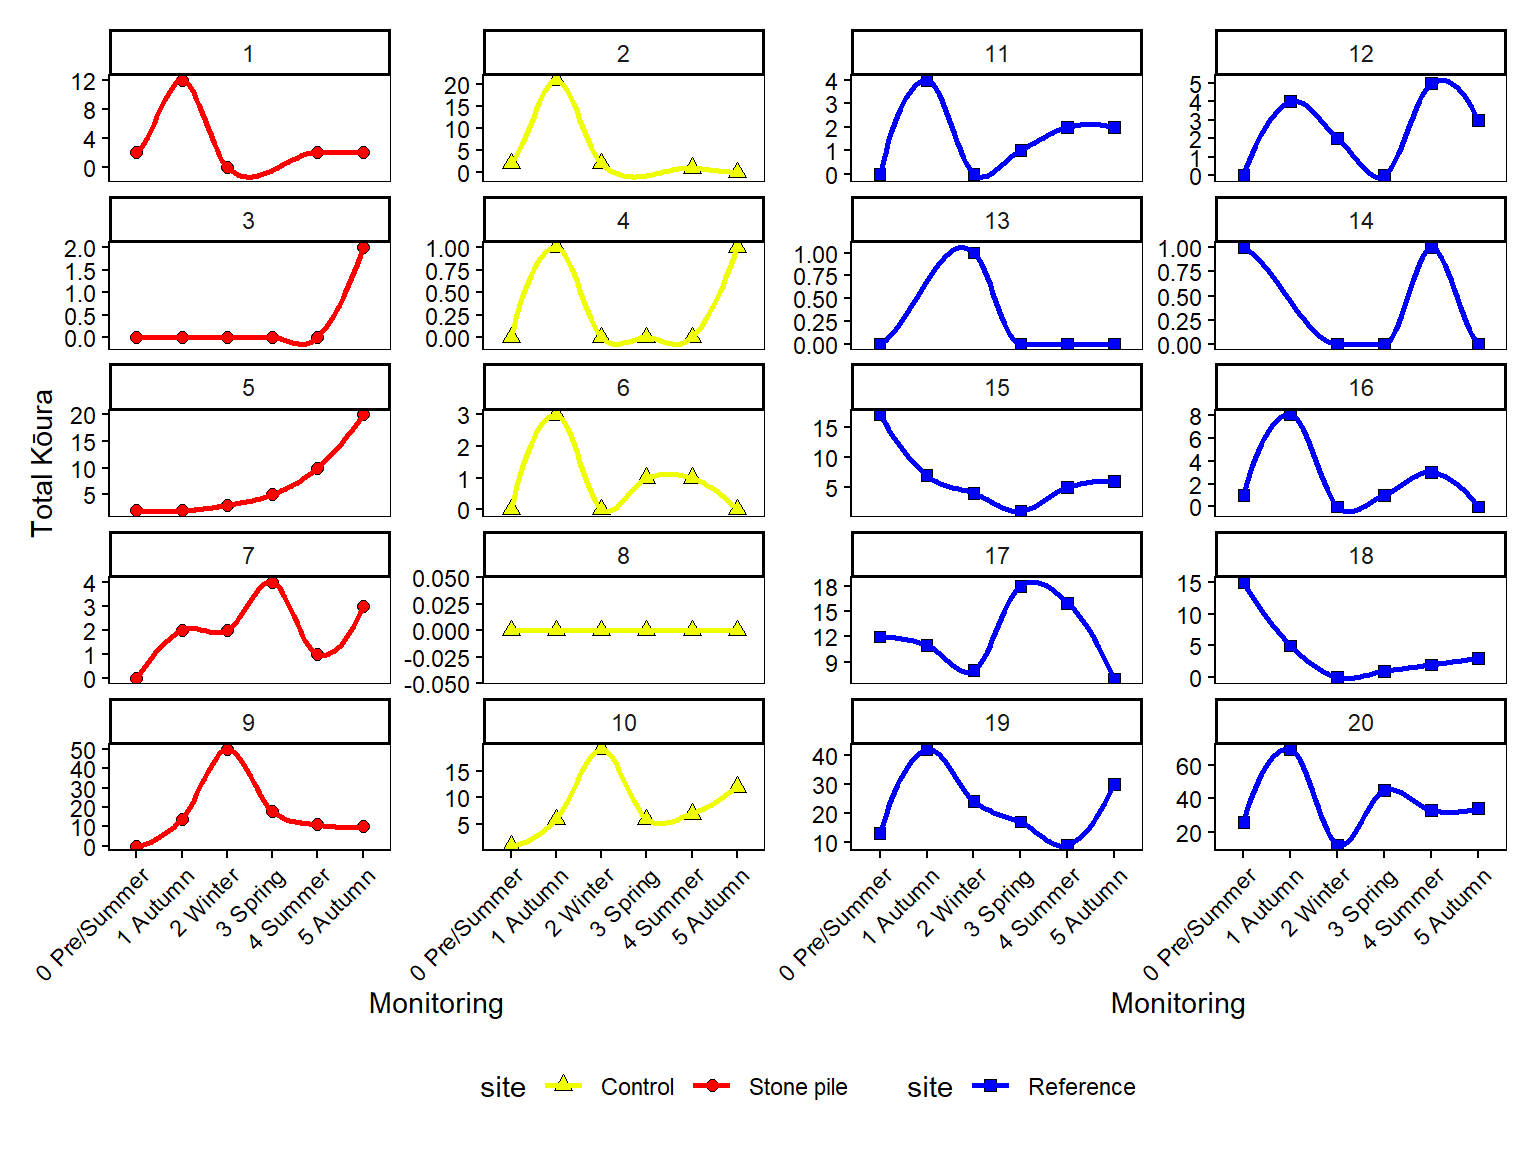

In [ ]:

koura_plot1 <- all_data %>%
   dplyr::filter(site != "Reference") %>%
    ggplot(aes(Monitoring_label, `Total_Individuals_Kōura`, shape = site, fill = site)) +
    geom_point(size = 2, col = "black") +
    geom_smooth(se = FALSE, aes(group = site, col = site)) +
    facet_wrap(~site_id, ncol=2, scales = "free_y") +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    labs(y = "Total Kōura", x = "Monitoring") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

koura_plot2 <- all_data %>%
  dplyr::filter(site == "Reference") %>%
    ggplot(aes(Monitoring_label, `Total_Individuals_Kōura`, shape = site, , fill = site)) +
    geom_point(size = 2, col = "black") +
    geom_smooth(se = FALSE, aes(group = site, col = site)) +
    facet_wrap(~site_id, ncol=2, scales = "free_y") +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    labs(y = "Total Kōura", x = "Monitoring") +
    theme(axis.title.y = element_blank()) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
 
combined_koura <- koura_plot1 + koura_plot2 + plot_layout(guides = "collect") & theme(legend.position = "bottom")

ggsave(file.path(out_dir, "fig-koura-abundance.png"), combined_koura, width = 400, height = 250, units = "mm", dpi = 300)


# Kōura trend plot

ℹ Results may be unexpected or may change in future versions of ggplot2.

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

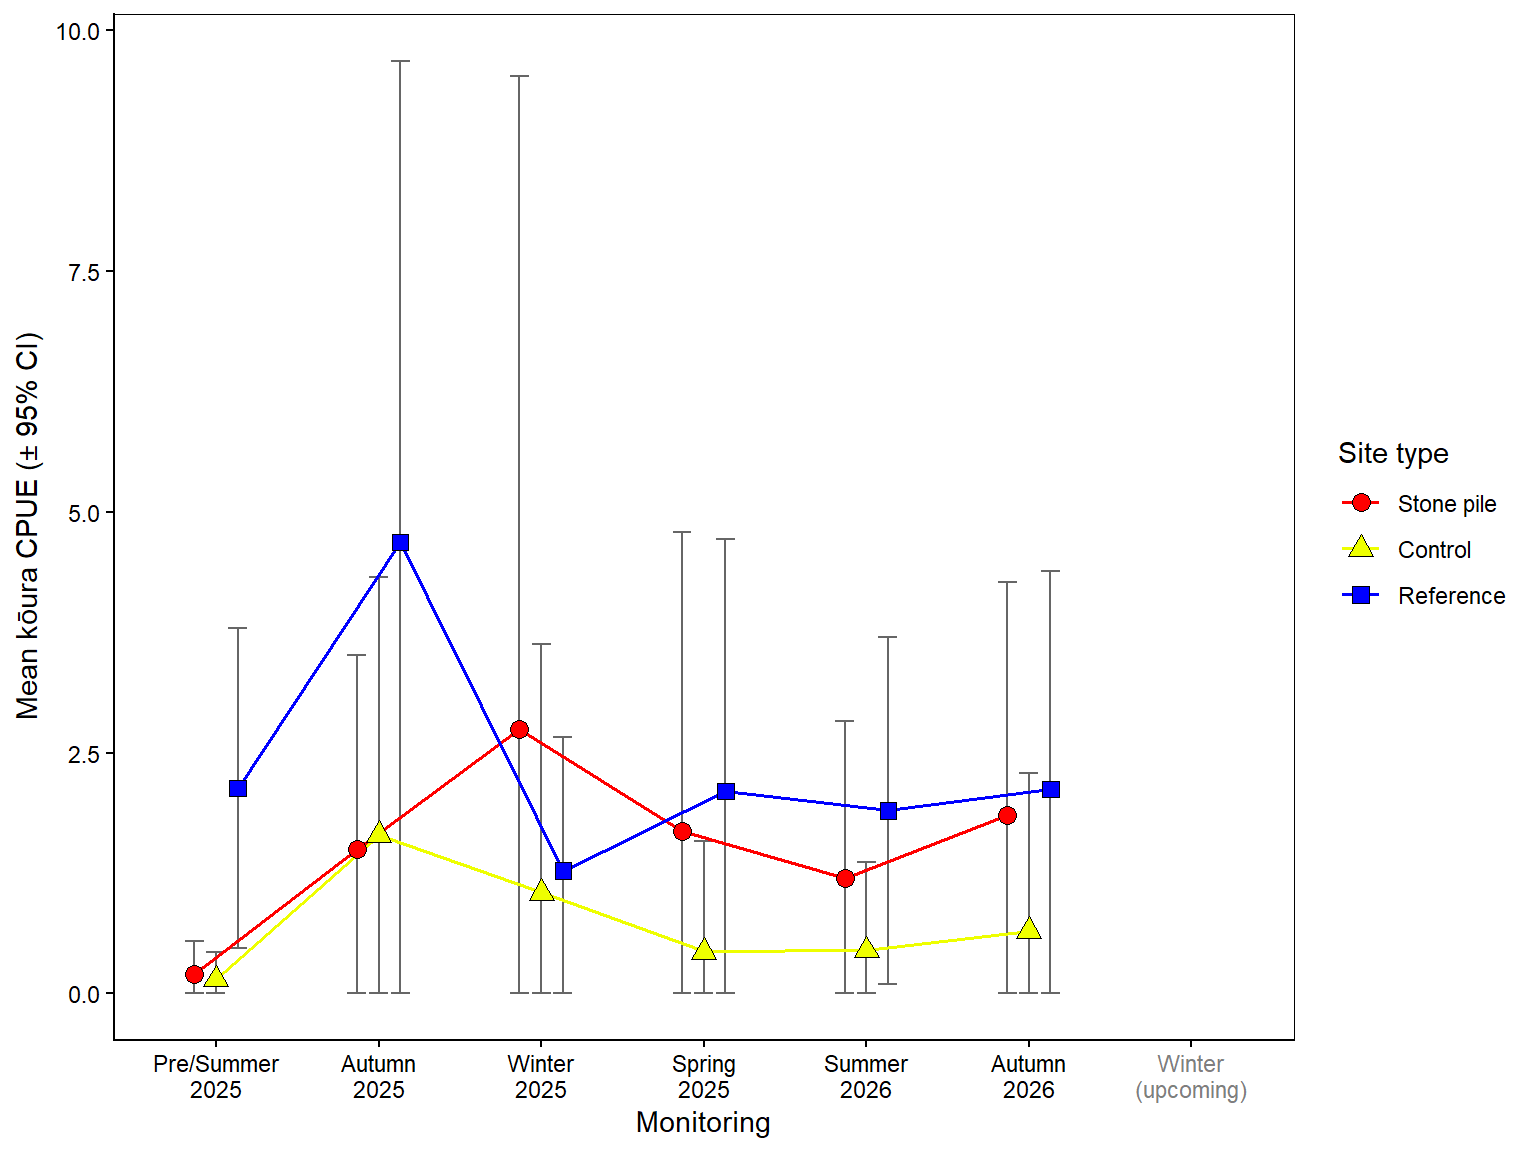

In [ ]:

koura_summary <- all_data %>%
  group_by(Monitoring_label, monitoring_int, site) %>%
  summarise(
    mean_cpue = mean(Weighted_CPUE_Kōura, na.rm = TRUE),
    se        = sd(Weighted_CPUE_Kōura, na.rm = TRUE) / sqrt(sum(!is.na(Weighted_CPUE_Kōura))),
    n         = sum(!is.na(Weighted_CPUE_Kōura)),
    ci95      = qt(0.975, df = pmax(n - 1, 1)) * se,
    .groups   = "drop") %>%
  mutate(
    site    = factor(site, levels = c("Stone_pile", "Control", "Reference")),
    ci_low  = pmax(mean_cpue - ci95, 0),
    ci_high = mean_cpue + ci95)

koura_trends <- ggplot(koura_summary, aes(monitoring_int , mean_cpue, shape = site, fill = site)) +
  geom_errorbar(aes(ymin = ci_low, ymax = ci_high), position = position_dodge(width = 0.4), width = 0.35, colour = "grey40") +
  geom_line(aes(group = site, col = site), position = position_dodge(width = 0.4), linewidth = 0.6) +
  geom_point(size = 3, stroke = 0.4, position = position_dodge(width = 0.4)) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(values = site_fill, labels = site_labels) +
  scale_shape_manual(values = site_shapes, labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(y = expression("Mean kōura CPUE (± 95% CI)"), x  = "Monitoring", col = "Site type", shape  = "Site type", fill = "Site type") +
  theme(axis.text.x = element_text(colour = c(rep("black", 6), "grey50")))


# Fish abundance

In [ ]:

species_vec <- c("Kōura", "Catfish", "Kōaro", "Goldfish")

make_metrics <- function(species) {
  cols <- c(
    paste0("Total_Individuals_", species),
    paste0("Weighted_CPUE_", species),
    paste0("Weighted_BPUE_", species))

  labels <- c(
    paste("Total", species),
    "Weighted CPUE",
    "Weighted BPUE")

  stats::setNames(labels, cols)
}

plots_by_species <- vector("list", length(species_vec))
names(plots_by_species) <- species_vec

for (sp in species_vec) {

  metrics_to_plot <- make_metrics(sp)

  metric_cols <- names(metrics_to_plot)
  metric_cols <- metric_cols[metric_cols %in% names(all_data)]
  if (length(metric_cols) == 0) next

  plot_data <- all_data %>%
    dplyr::mutate(monitoring_int = factor(monitoring_int)) %>%
    tidyr::pivot_longer( cols = dplyr::all_of(metric_cols),  names_to  = "Metric", values_to = "Value") %>%
    dplyr::mutate(Metric = factor(Metric, levels = metric_cols,  labels = unname(metrics_to_plot[metric_cols])))

  p_nonref <- plot_data %>%
    dplyr::filter(site != "Reference") %>%
    ggplot(aes(monitoring_int, Value, col = site)) +
    geom_point(size = 2) +
    geom_smooth(se = FALSE, aes(group = site)) +
    facet_grid(Metric ~ site_id, scales = "free_y") +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(  values = site_colours, labels = site_labels) +
    labs(x = NULL, y = NULL) +
    theme(axis.text.x = element_blank())

  p_ref <- plot_data %>%
    dplyr::filter(site == "Reference") %>%
    ggplot(aes(monitoring_int, Value, col = site)) +
    geom_point(size = 2) +
    geom_smooth(se = FALSE, aes(group = site)) +
    facet_grid(Metric ~ site_id, scales = "free_y") +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(  values = site_colours, labels = site_labels) +
    labs(x = "Monitoring", y = NULL) +
    theme(axis.title.y = element_blank()) +
    theme(axis.text.x = element_text(hjust = 1))

  combined_plot <- p_nonref + p_ref +
    patchwork::plot_layout(guides = "collect", ncol = 1) &
    theme(legend.position = "bottom")

  out_name <- paste0(sp, "_plots.png")

  ggsave(
    filename = file.path(out_dir, out_name),
    plot     = combined_plot,
    width    = 400,
    height   = 250,
    units    = "mm",
    dpi      = 300
  )

  plots_by_species[[sp]] <- combined_plot
}


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 0.975

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2.025

...

(`geom_point()`).

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

# Fish trends

In [ ]:

# Species to plot and their display names
species_vec_trends <- c("Kōura", "Catfish", "Kōaro", "Goldfish")

species_labels <- c("Kōura"= "Kōura","Catfish"= "Catfish", "Kōaro"= "Kōaro","Goldfish"= "Goldfish")

# Function to build one trend plot per species
make_trend_plot <- function(sp) {

  col_name <- paste0("Total_Individuals_", sp)
  if (!col_name %in% names(all_data)) return(NULL)

  summary_df <- all_data %>%
    group_by(monitoring_int, site) %>%
    summarise(
      mean_n = mean(.data[[col_name]], na.rm = TRUE),
      se     = sd(.data[[col_name]], na.rm = TRUE) /
               sqrt(sum(!is.na(.data[[col_name]]))),
      n      = sum(!is.na(.data[[col_name]])),
      ci95   = qt(0.975, df = pmax(n - 1, 1)) * se,
      .groups = "drop") %>%
    mutate(
      site   = factor(site, levels = c("Stone_pile", "Control", "Reference")),
      ci_low  = pmax(mean_n - ci95, 0),
      ci_high = mean_n + ci95)

  ggplot(summary_df,
      aes(monitoring_int, mean_n,
          colour = site, shape = site, fill = site)) +
    geom_errorbar(aes(ymin = ci_low, ymax = ci_high),
                  position = position_dodge(width = 0.4),
                  width = 0.25, linewidth = 0.4, colour = "grey40") +
    geom_line(aes(group = site),
              position = position_dodge(width = 0.4),
              linewidth = 0.6) +
    geom_point(size = 2.5, stroke = 0.4,
               position = position_dodge(width = 0.4)) +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    scale_x_continuous(
      breaks = 0:6,
      labels = monitor_labels,
      limits = c(-0.3, 6.3)) +
    labs(
      title  = species_labels[[sp]],
      x      = NULL,
      y      = "Mean caught (± 95% CI)",
      colour = "Site type",
      shape  = "Site type",
      fill   = "Site type") +
    theme(
      axis.text.x     = element_text(size = 7,
        colour = c(rep("black", 6), "grey50")),
      axis.text.y     = element_text(size = 8),
      axis.title.y    = element_text(size = 9),
      plot.title      = element_text(size = 10, face = "bold"),
      legend.position = "none")   # collect legend from patchwork
}

# Generate all plots, drop NULLs
trend_plots <- purrr::map(species_vec_trends, make_trend_plot) %>%
  purrr::set_names(species_vec_trends) %>%
  purrr::compact()


ℹ Results may be unexpected or may change in future versions of ggplot2.
Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.
Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.
Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

# Chemical & Habitat Plot

In [ ]:

Chemical_data2 <- all_data %>%
  dplyr::select(monitoring_id, site_id, site, Monitoring_label, Habitat_Type, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH, Temperature) %>%
  tidyr::pivot_longer(cols = c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), names_to = "Variable", values_to = "Values") 

Chemical_plot <- ggplot(Chemical_data2, aes(Monitoring_label, Values, col = site_id)) +
  geom_point() +
  geom_smooth(se = FALSE, aes(group = site_id)) +
  facet_wrap(~ Variable, scales = "free", nrow = 2) +
  labs(y = "Value", x = "Monitoring") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#ggsave(file.path(out_dir, "Chemical_plot.png"), Chemical_plot, width = 10, height = 8,  dpi = 300)

Chemical_plot


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 0.975

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 3.025

...

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4.1006

(`geom_point()`).

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

# BACI

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
Weighted_CPUE_Kōura ~ Period * site + Temperature + Substrate_index +  
    (1 | site_id)
   Data: all_data

REML criterion at convergence: 460.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4929 -0.4183 -0.1114  0.0940  5.2593 

Random effects:
 Groups   Name        Variance Std.Dev.
 site_id  (Intercept) 3.499    1.871   
 Residual             2.418    1.555   
Number of obs: 114, groups:  site_id, 20

Fixed effects:
                           Estimate Std. Error       df t value Pr(>|t|)
(Intercept)                -1.34188    2.35020 33.31876  -0.571    0.572
PeriodAfter                 0.63902    0.85006 89.89779   0.752    0.454
siteReference               1.19040    1.53020 28.01856   0.778    0.443
siteStone_pile              0.19164    1.54444 34.15461   0.124    0.902
Temperature                -0.01259    0.04772 90.43041  -0.264    0.793
Substrate_index         

Type III Analysis of Variance Table with Satterthwaite's method
                Sum Sq Mean Sq NumDF  DenDF F value Pr(>F)
Period          3.0940  3.0940     1 90.022  1.2796 0.2610
site            0.8552  0.4276     2 17.814  0.1769 0.8394
Temperature     0.1682  0.1682     1 90.430  0.0696 0.7926
Substrate_index 2.6604  2.6604     1 15.958  1.1002 0.3098
Period:site     9.2568  4.6284     2 89.806  1.9142 0.1534

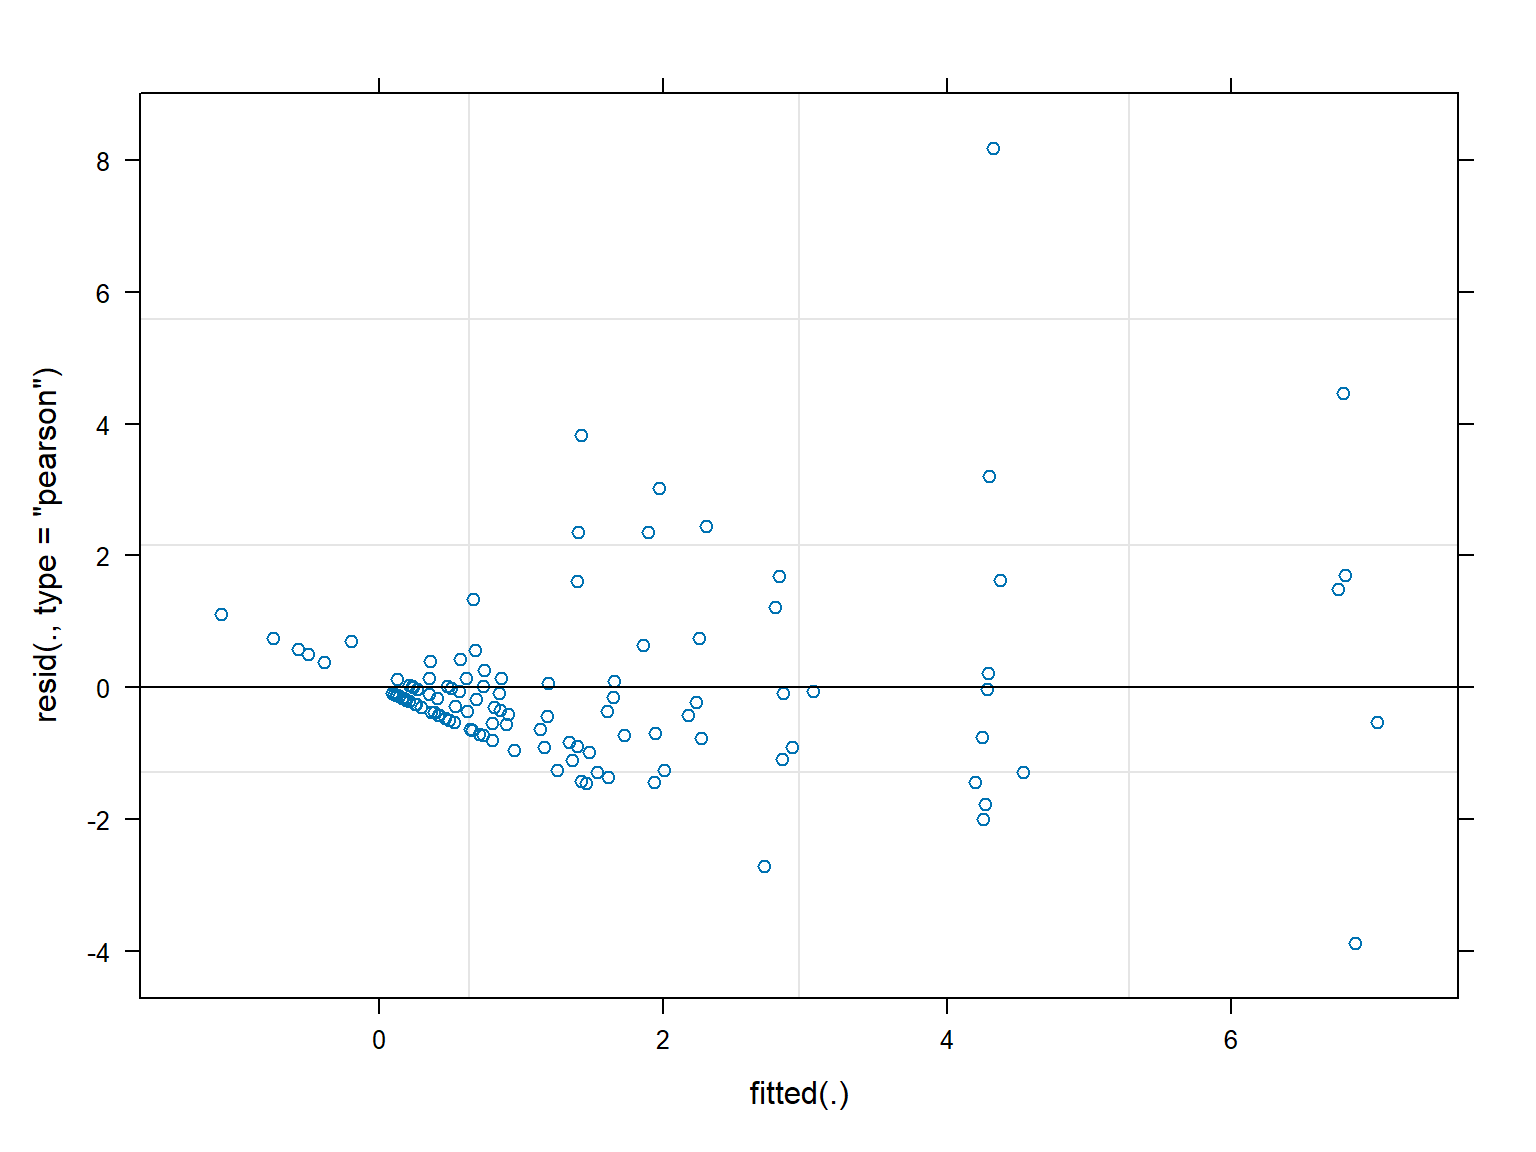

Period = Before:
 contrast               estimate   SE   df t.ratio p.value
 Control - Reference      -1.190 1.53 28.4  -0.778  0.7194
 Control - Stone_pile     -0.192 1.54 34.5  -0.124  0.9915
 Reference - Stone_pile    0.999 1.60 26.9   0.624  0.8084

Period = After:
 contrast               estimate   SE   df t.ratio p.value
 Control - Reference      -0.238 1.33 16.7  -0.179  0.9826
 Control - Stone_pile     -1.041 1.27 16.7  -0.818  0.6975
 Reference - Stone_pile   -0.803 1.42 16.7  -0.567  0.8394

Degrees-of-freedom method: kenward-roger 
P value adjustment: tukey method for comparing a family of 3 estimates 

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log1p(Weighted_CPUE_Catfish) ~ Period * site + Temperature +  
    Substrate_index + (1 | site_id)
   Data: all_data

REML criterion at convergence: 73.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8449 -0.4113 -0.1683  0.2127  4.6836 

Random effects:
 Groups   Name        Variance Std.Dev.
 site_id  (Intercept) 0.03316  0.1821  
 Residual             0.07239  0.2691  
Number of obs: 114, groups:  site_id, 20

Fixed effects:
                            Estimate Std. Error        df t value Pr(>|t|)   
(Intercept)                -0.690043   0.311737 62.125423  -2.214  0.03054 * 
PeriodAfter                 0.173939   0.147013 90.341590   1.183  0.23986   
siteReference               0.062324   0.195837 49.928845   0.318  0.75163   
siteStone_pile             -0.022946   0.206004 64.624465  -0.111  0.91166   
Temperature                 0.024702   0.008235 91.674859   3.000

Type III Analysis of Variance Table with Satterthwaite's method
                 Sum Sq Mean Sq NumDF  DenDF F value   Pr(>F)   
Period          0.34597 0.34597     1 90.655  4.7792 0.031381 * 
site            0.01321 0.00661     2 21.462  0.0913 0.913136   
Temperature     0.65143 0.65143     1 91.675  8.9987 0.003479 **
Substrate_index 0.05246 0.05246     1 16.492  0.7247 0.406794   
Period:site     0.01876 0.00938     2 90.108  0.1296 0.878637   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [ ]:

baci_koura_cpue <- lmer(Weighted_CPUE_Kōura ~ Period * site + Temperature + Substrate_index + (1 | site_id), data = all_data)

summary(baci_koura_cpue)


# BACI models

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log1p(Weighted_CPUE_Kōura) ~ Period * site + monitoring_int +  
    Temperature + Substrate_index + (1 | pair_id/site_id)
   Data: baci_data
Control: lmerControl(optimizer = "bobyqa")

REML criterion at convergence: 98.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9715 -0.5330 -0.1600  0.4256  2.8106 

Random effects:
 Groups          Name        Variance Std.Dev.
 site_id:pair_id (Intercept) 0.01707  0.1306  
 pair_id         (Intercept) 0.22250  0.4717  
 Residual                    0.18907  0.4348  
Number of obs: 58, groups:  site_id:pair_id, 10; pair_id, 5

Fixed effects:
                            Estimate Std. Error        df t value Pr(>|t|)
(Intercept)                 0.255396   0.793463 19.044479   0.322    0.751
PeriodAfter                 0.430543   0.323939 44.169562   1.329    0.191
siteStone_pile              0.023071   0.290332 27.451008   0.079    0.937
m

Type III Analysis of Variance Table with Satterthwaite's method
                 Sum Sq Mean Sq NumDF  DenDF F value  Pr(>F)  
Period          0.76821 0.76821     1 44.205  4.0631 0.04993 *
site            0.17037 0.17037     1  5.898  0.9011 0.37974  
monitoring_int  0.13959 0.13959     1 44.050  0.7383 0.39485  
Temperature     0.00125 0.00125     1 44.424  0.0066 0.93551  
Substrate_index 0.01863 0.01863     1  5.426  0.0985 0.76532  
Period:site     0.17629 0.17629     1 44.044  0.9324 0.33951  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Period = Before:
 contrast             estimate    SE   df t.ratio p.value
 Control - Stone_pile  -0.0231 0.292 30.4  -0.079  0.9375

Period = After:
 contrast             estimate    SE   df t.ratio p.value
 Control - Stone_pile  -0.3151 0.161  4.3  -1.955  0.1173

Note: contrasts are still on the log1p scale. Consider using
      regrid() if you want contrasts of back-transformed estimates. 
Degrees-of-freedom method: kenward-roger 

 Period_consec  site_pairwise        estimate    SE df t.ratio p.value
 After - Before Control - Stone_pile   -0.292 0.302 44  -0.965  0.3397

Degrees-of-freedom method: kenward-roger 

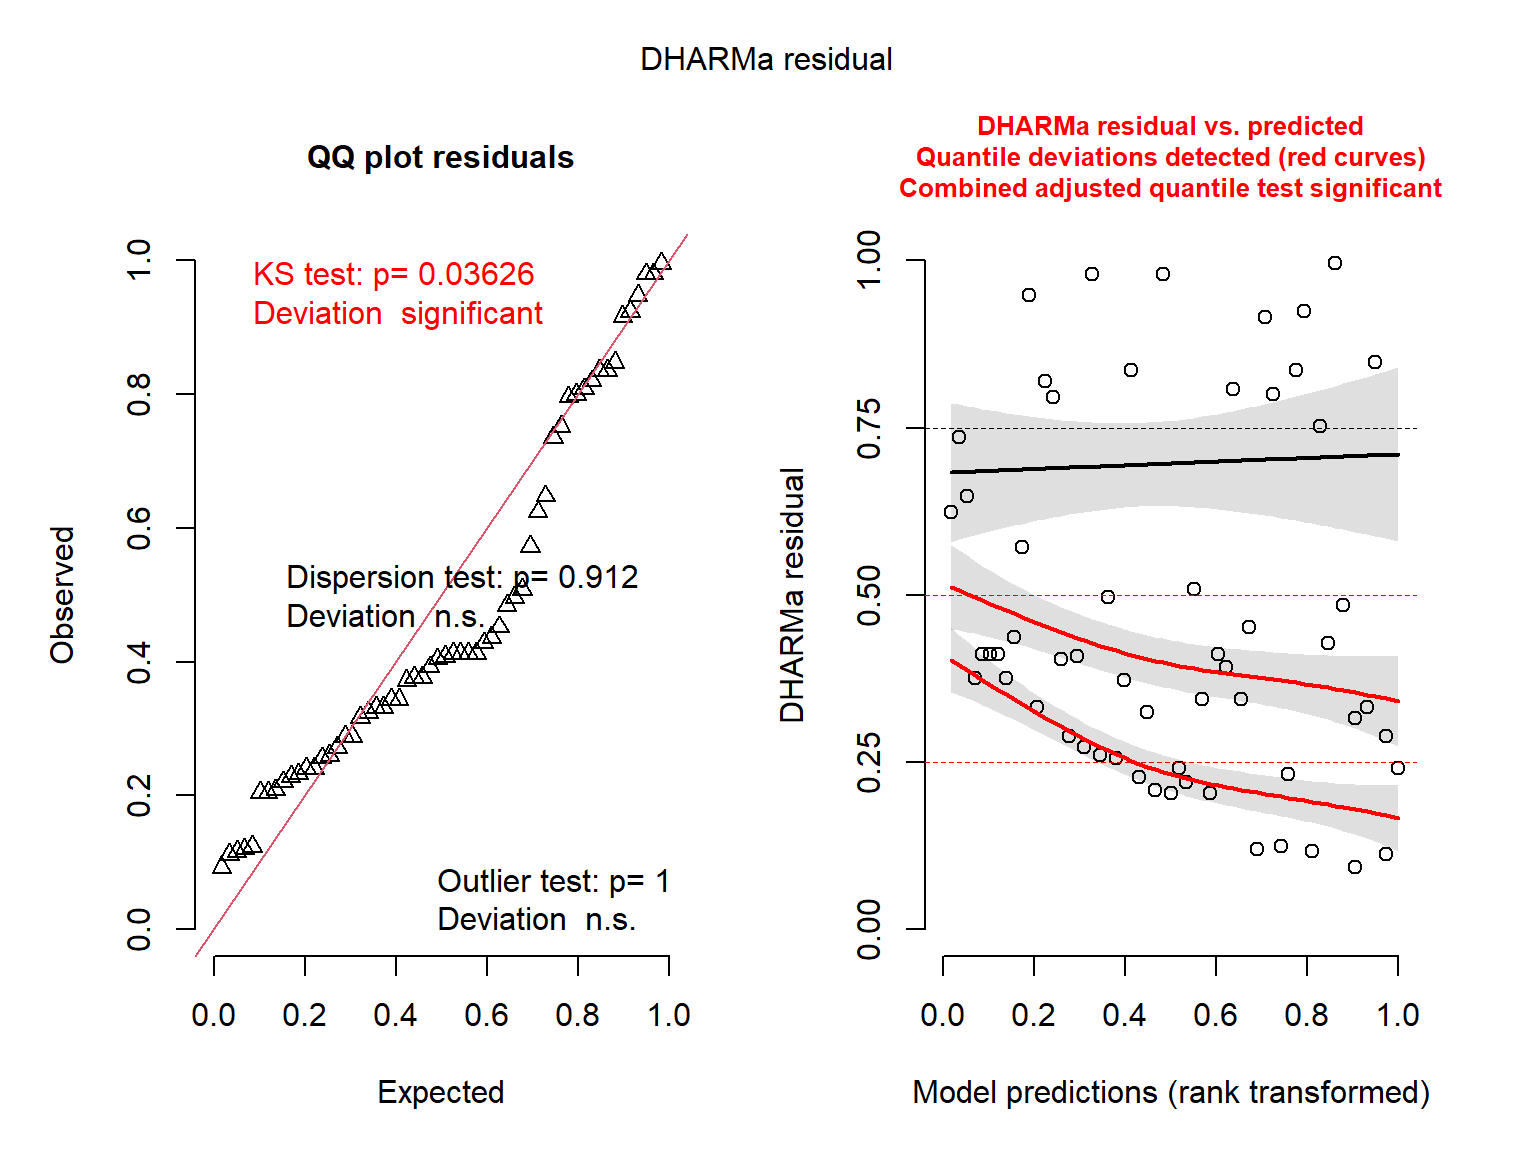

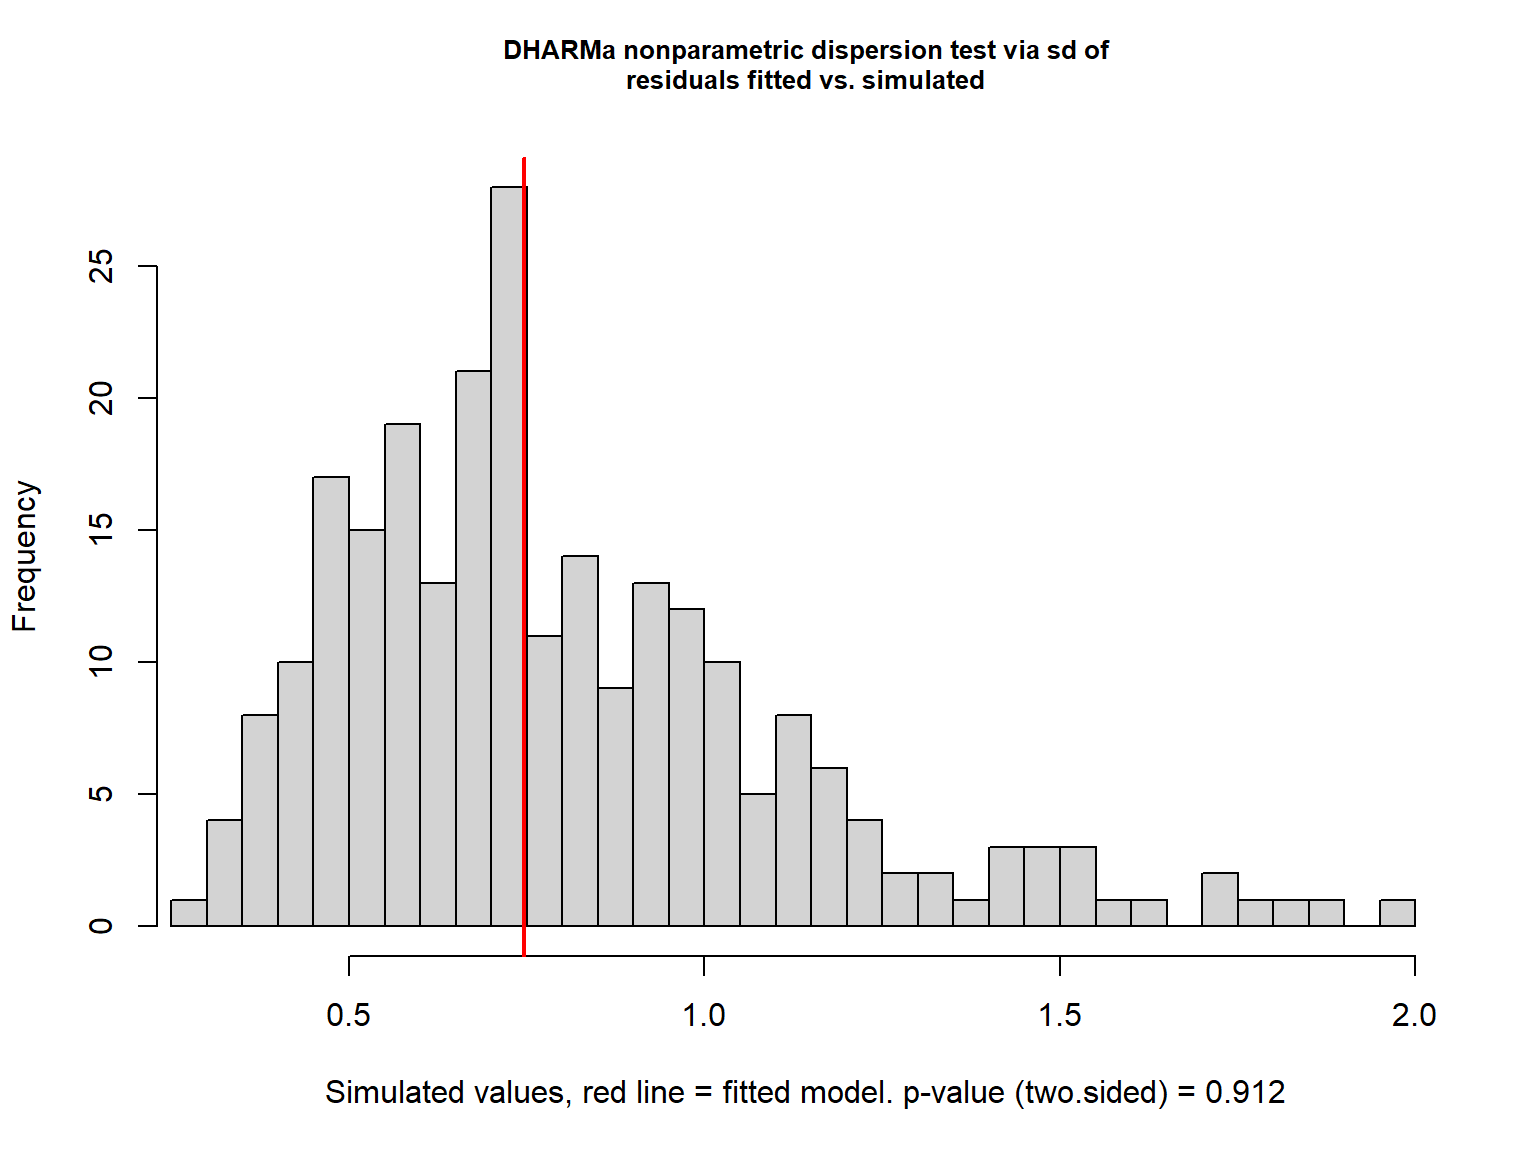


    DHARMa nonparametric dispersion test via sd of residuals fitted vs.
    simulated

data:  simulationOutput
dispersion = 0.93088, p-value = 0.912
alternative hypothesis: two.sided

 Family: binomial  ( logit )
Formula:          
koura_present ~ Period * site + monitoring_int + Temperature +  
    Substrate_index + (1 | pair_id/site_id)
Data: baci_data

      AIC       BIC    logLik -2*log(L)  df.resid 
     72.9      91.4     -27.4      54.9        49 

Random effects:

Conditional model:
 Groups          Name        Variance Std.Dev.
 site_id:pair_id (Intercept) 2.8703   1.6942  
 pair_id         (Intercept) 0.6812   0.8253  
Number of obs: 58, groups:  site_id:pair_id, 10; pair_id, 5

Conditional model:
                           Estimate Std. Error z value Pr(>|z|)  
(Intercept)                -11.1854     5.7100  -1.959   0.0501 .
PeriodAfter                  3.6799     2.4436   1.506   0.1321  
siteStone_pile               0.2189     2.0452   0.107   0.9148  
monitoring_int              -0.1852     0.3225  -0.574   0.5658  
Temperature                  0.2478     0.1656   1.496   0.1347  
Substrate_index              0.1973     0.1505   1.311   0.1899  
Peri

Analysis of Deviance Table (Type III Wald chisquare tests)

Response: koura_present
                 Chisq Df Pr(>Chisq)  
(Intercept)     3.8374  1    0.05012 .
Period          2.2678  1    0.13209  
site            0.0115  1    0.91475  
monitoring_int  0.3298  1    0.56577  
Temperature     2.2377  1    0.13468  
Substrate_index 1.7183  1    0.18992  
Period:site     0.9001  1    0.34274  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Period = Before:
 contrast             odds.ratio    SE  df null z.ratio p.value
 Control / Stone_pile      0.803 1.640 Inf    1  -0.107  0.9148

Period = After:
 contrast             odds.ratio    SE  df null z.ratio p.value
 Control / Stone_pile      0.118 0.178 Inf    1  -1.420  0.1555

Tests are performed on the log odds ratio scale 

 Period_consec  site_pairwise        odds.ratio    SE  df null z.ratio p.value
 After / Before Control / Stone_pile      0.147 0.298 Inf    1  -0.949  0.3427

Tests are performed on the log odds ratio scale 

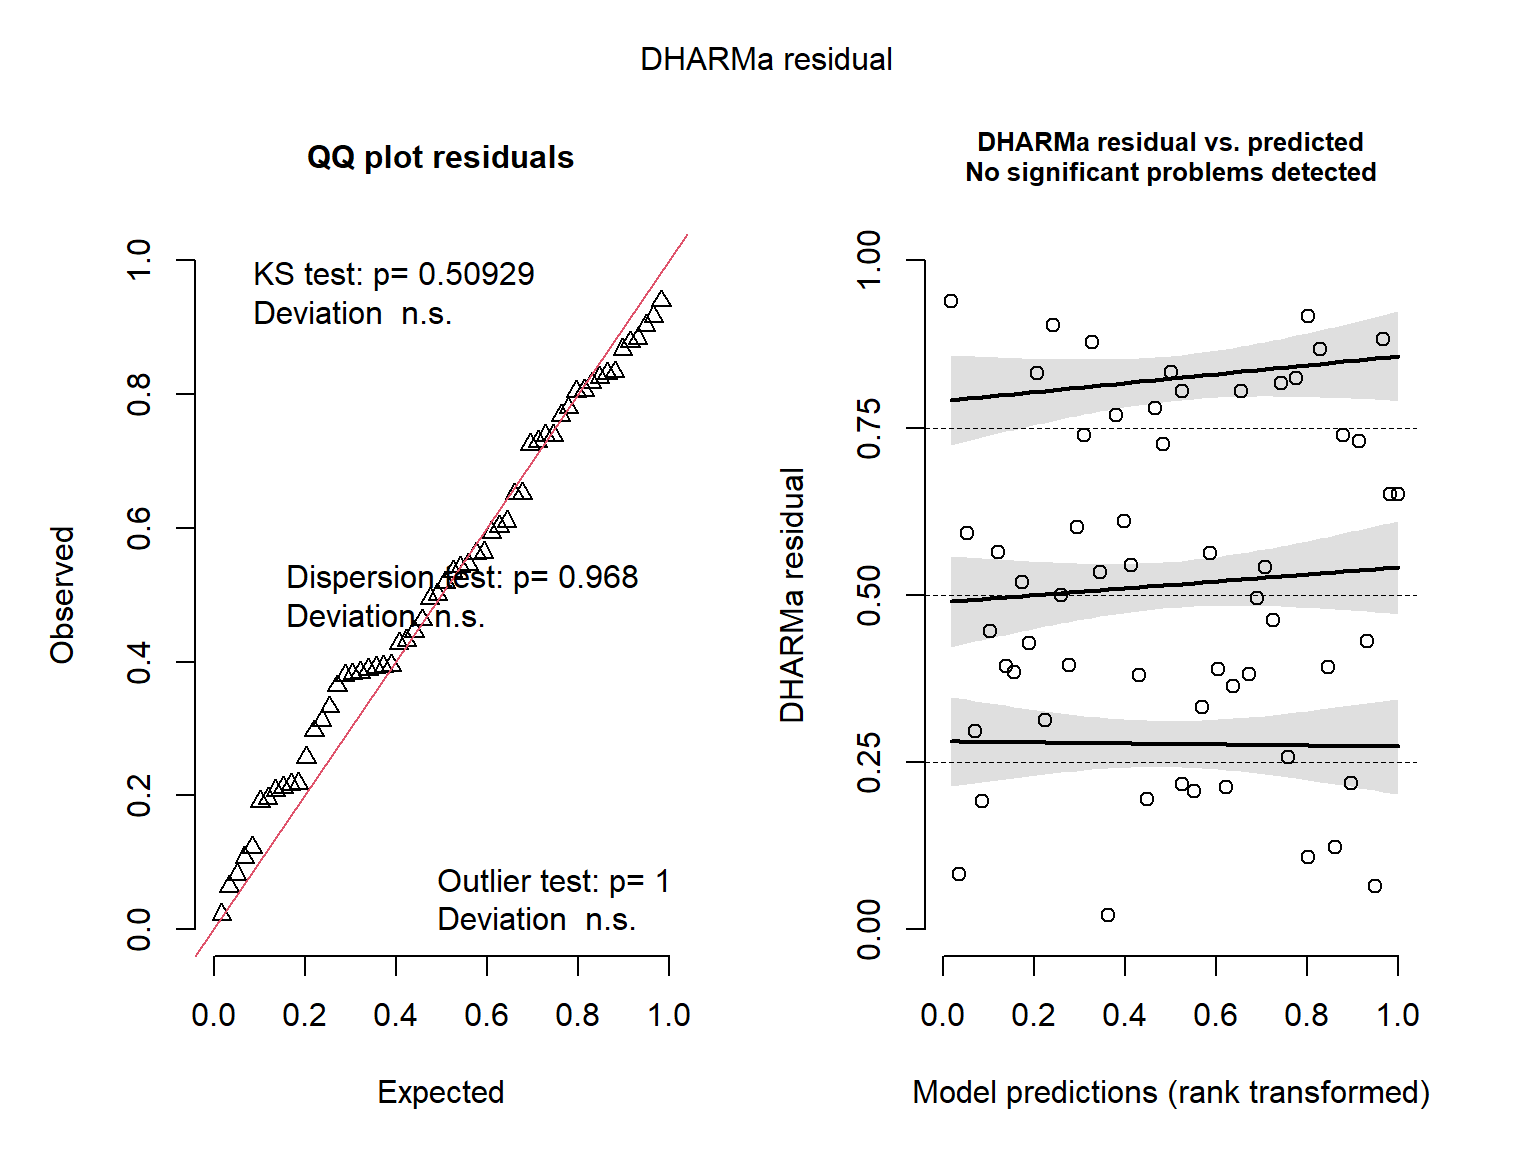

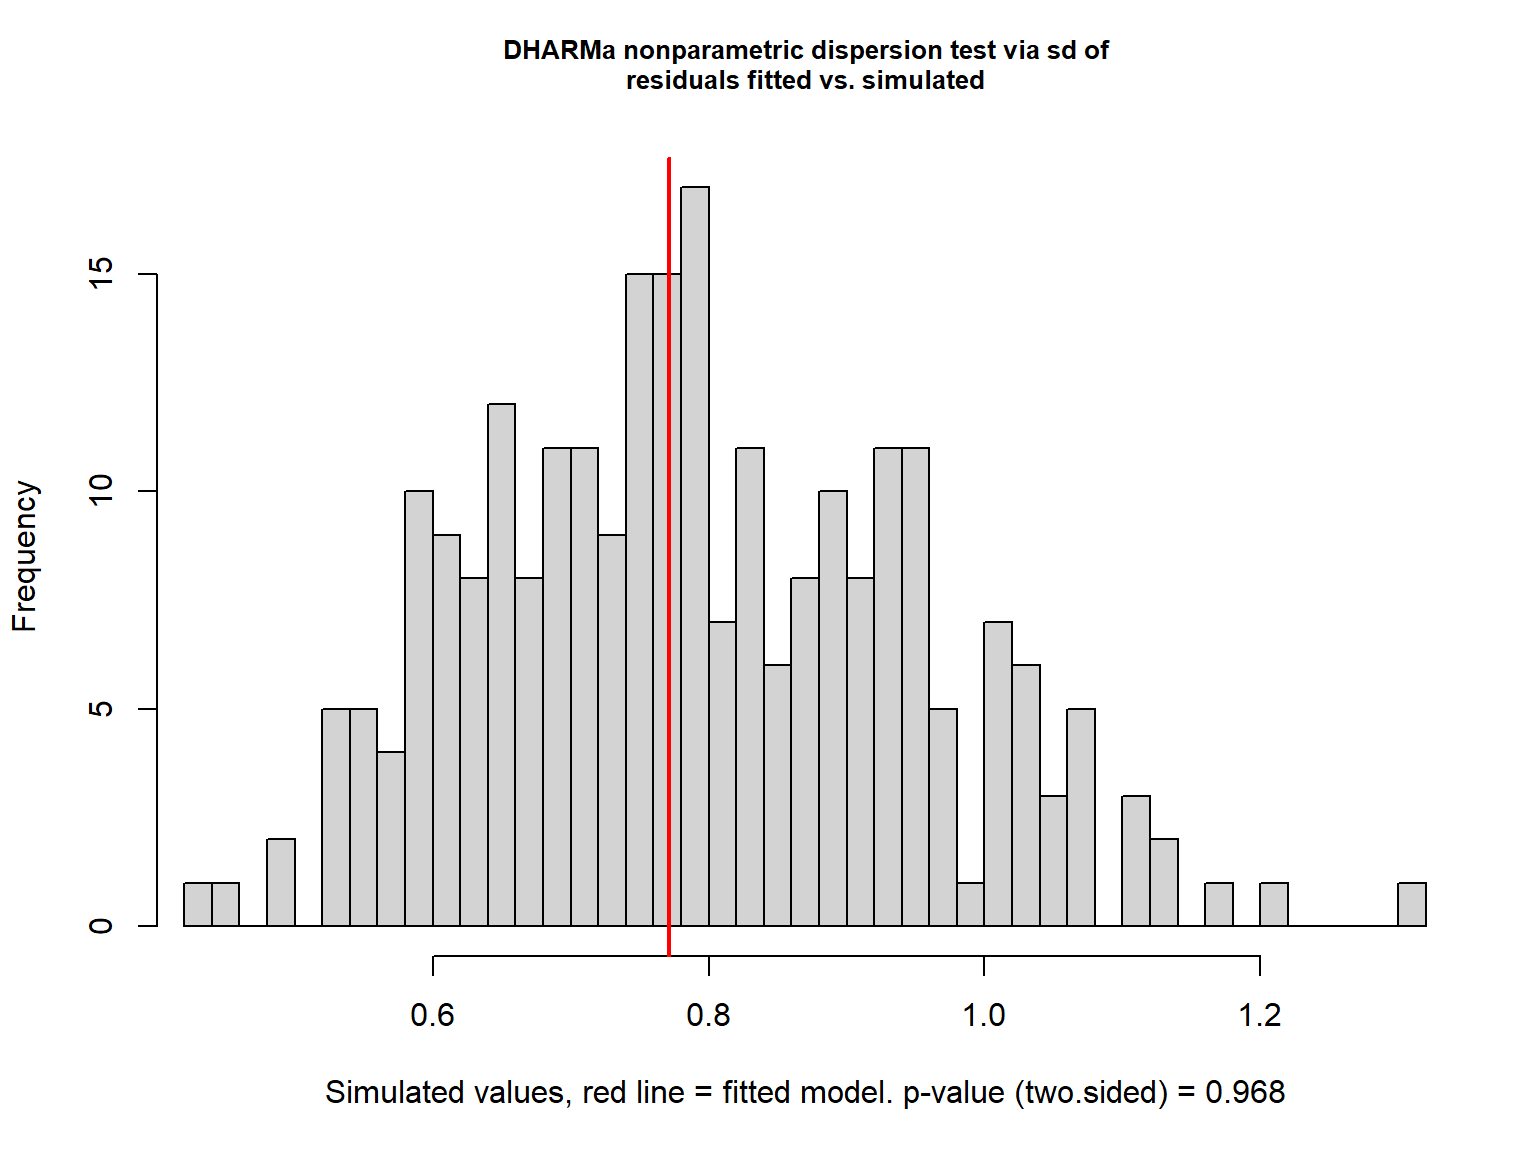


    DHARMa nonparametric dispersion test via sd of residuals fitted vs.
    simulated

data:  simulationOutput
dispersion = 0.97322, p-value = 0.968
alternative hypothesis: two.sided

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log1p(Weighted_CPUE_Kōura) ~ site * monitoring_int + Temperature +  
    Substrate_index + (1 | site_id)
   Data: convergence_data
Control: lmerControl(optimizer = "bobyqa")

REML criterion at convergence: 151.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.6181 -0.5441 -0.1041  0.3952  3.0831 

Random effects:
 Groups   Name        Variance Std.Dev.
 site_id  (Intercept) 0.3998   0.6323  
 Residual             0.1778   0.4217  
Number of obs: 85, groups:  site_id, 15

Fixed effects:
                                Estimate Std. Error         df t value Pr(>|t|)
(Intercept)                    0.1404422  0.9726690 13.7793685   0.144   0.8873
siteStone_pile                -0.1631702  0.5089524 14.1874997  -0.321   0.7532
monitoring_int                -0.0192786  0.0332253 66.9949545  -0.580   0.5637
Temperature                   -0.0008115  0.0114790 67.0939855  -0.071   0.943

Type III Analysis of Variance Table with Satterthwaite's method
                     Sum Sq Mean Sq NumDF  DenDF F value  Pr(>F)  
site                0.01828 0.01828     1 14.187  0.1028 0.75319  
monitoring_int      0.31437 0.31437     1 66.954  1.7680 0.18815  
Temperature         0.00089 0.00089     1 67.094  0.0050 0.94385  
Substrate_index     0.10423 0.10423     1 12.040  0.5861 0.45866  
site:monitoring_int 0.74606 0.74606     1 66.945  4.1957 0.04445 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

[1] "site"           "monitoring_int" "response"       "SE"            
[5] "df"             "lower.CL"       "upper.CL"      

monitoring_int = 0:
 contrast                 estimate        SE    df t.ratio p.value
 Stone_pile - Reference -0.1631702 0.5089567 14.28  -0.321  0.7532

monitoring_int = 1:
 contrast                 estimate        SE    df t.ratio p.value
 Stone_pile - Reference -0.0485713 0.4962396 12.92  -0.098  0.9235

monitoring_int = 2:
 contrast                 estimate        SE    df t.ratio p.value
 Stone_pile - Reference  0.0660276 0.4896236 12.25   0.135  0.8949

monitoring_int = 3:
 contrast                 estimate        SE    df t.ratio p.value
 Stone_pile - Reference  0.1806266 0.4893561 12.22   0.369  0.7184

monitoring_int = 4:
 contrast                 estimate        SE    df t.ratio p.value
 Stone_pile - Reference  0.2952255 0.4954473 12.84   0.596  0.5616

monitoring_int = 5:
 contrast                 estimate        SE    df t.ratio p.value
 Stone_pile - Reference  0.4098244 0.5076685 14.14   0.807  0.4329

monitoring_int = 6:
 contrast                 estimate        SE    df

...

(`geom_point()`).

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

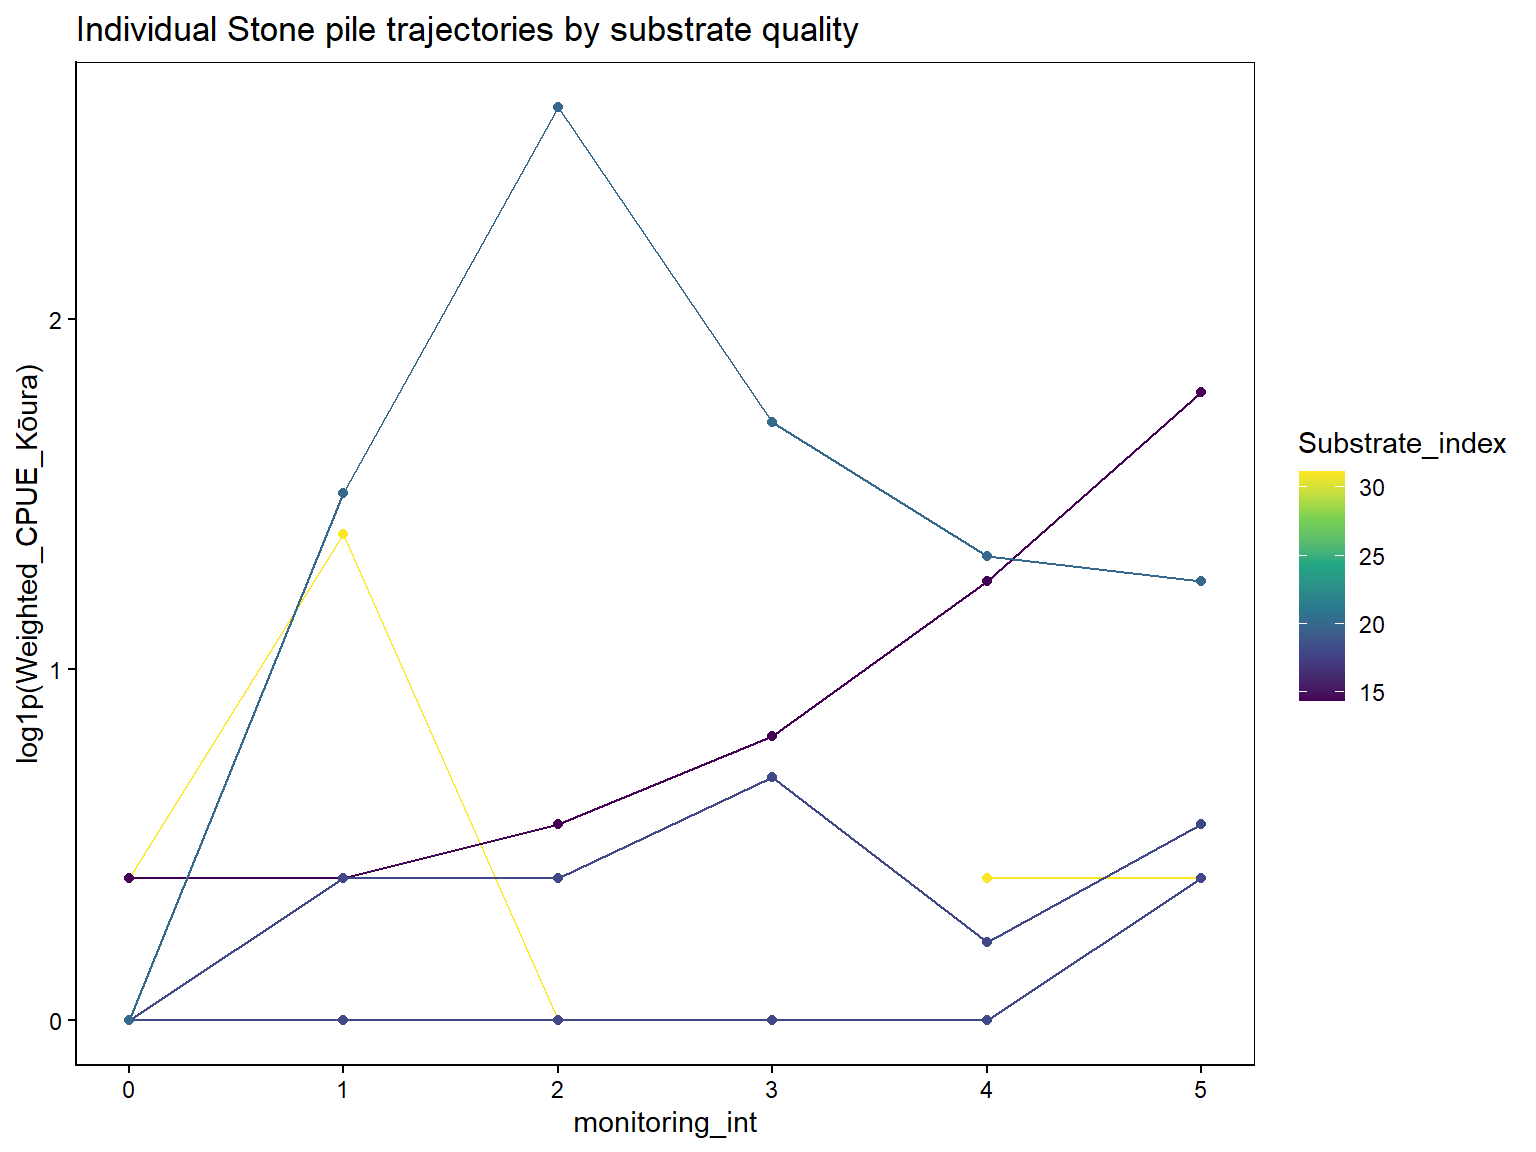

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log1p(Weighted_BPUE_Kōura) ~ site * monitoring_int + Temperature +  
    Substrate_index + (1 | site_id)
   Data: convergence_data
Control: lmerControl(optimizer = "bobyqa")

REML criterion at convergence: 329.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.10306 -0.58553  0.07915  0.58321  2.03594 

Random effects:
 Groups   Name        Variance Std.Dev.
 site_id  (Intercept) 1.56     1.249   
 Residual             1.94     1.393   
Number of obs: 85, groups:  site_id, 15

Fixed effects:
                              Estimate Std. Error       df t value Pr(>|t|)  
(Intercept)                    0.10544    2.14628 16.59678   0.049   0.9614  
siteStone_pile                -0.42804    1.13335 17.70010  -0.378   0.7102  
monitoring_int                -0.04590    0.10971 67.04807  -0.418   0.6770  
Temperature                    0.01973    0.03788 67.29435   0.521   0.6042 

Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value  Pr(>F)  
site                0.2767  0.2767     1 17.700  0.1426 0.71016  
monitoring_int      2.9519  2.9519     1 66.949  1.5215 0.22171  
Temperature         0.5263  0.5263     1 67.294  0.2713 0.60420  
Substrate_index     2.3700  2.3700     1 12.159  1.2216 0.29045  
site:monitoring_int 5.9932  5.9932     1 66.925  3.0891 0.08339 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log1p(Weighted_CPUE_Kōura) ~ site + monitoring_int + Temperature +  
    Substrate_index + (1 | site_id) + lunar_illumination + site:monitoring_int
   Data: convergence_data
Control: lmerControl(optimizer = "bobyqa")

REML criterion at convergence: 150.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.5880 -0.5332 -0.0602  0.3989  3.3979 

Random effects:
 Groups   Name        Variance Std.Dev.
 site_id  (Intercept) 0.4050   0.6364  
 Residual             0.1742   0.4173  
Number of obs: 85, groups:  site_id, 15

Fixed effects:
                                Estimate Std. Error         df t value Pr(>|t|)
(Intercept)                    0.2840126  0.9813807 13.9776774   0.289   0.7765
siteStone_pile                -0.2421096  0.5136380 14.4047185  -0.471   0.6444
monitoring_int                -0.0389130  0.0353583 66.0826093  -1.101   0.2751
Temperature                    0.00

         df      AIC
m3_conv   8 167.2970
m9_lunar  9 168.3808

# A tibble: 1 × 4
  term                       estimate std.error p.value
  <chr>                         <dbl>     <dbl>   <dbl>
1 PeriodAfter:siteStone_pile    0.315     0.304   0.307

# A tibble: 1 × 4
  term                          estimate std.error p.value
  <chr>                            <dbl>     <dbl>   <dbl>
1 siteStone_pile:monitoring_int    0.112    0.0548  0.0446

# A tibble: 20 × 8
   model           term  estimate std.error statistic p.value conf.low conf.high
   <chr>           <chr>    <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
 1 M1 CPUE (lmer)  (Int…   0.255     0.794     0.322   0.751   -1.41      1.92  
 2 M1 CPUE (lmer)  Peri…   0.430     0.324     1.33    0.191   -0.222     1.08  
 3 M1 CPUE (lmer)  site…   0.0231    0.290     0.0795  0.937   -0.572     0.618 
 4 M1 CPUE (lmer)  moni…  -0.0397    0.0462   -0.859   0.395   -0.133     0.0534
 5 M1 CPUE (lmer)  Temp…   0.0017    0.0204    0.0814  0.936   -0.0394    0.0427
 6 M1 CPUE (lmer)  Subs…  -0.0077    0.0246   -0.314   0.765   -0.0696    0.0541
 7 M1 CPUE (lmer)  Peri…   0.292     0.302     0.966   0.340   -0.317     0.901 
 8 M2 Occupancy (… (Int… -11.2       5.71     -1.96    0.0501 -22.4       0.006 
 9 M2 Occupancy (… Peri…   3.68      2.44      1.51    0.132   -1.11      8.47  
10 M2 Occupancy (… site…   0.219     2.05      0.107   0.915   -3.79      4.23  
11 M2 Occ

In [ ]:
# KŌURA ANALYTICAL FRAMEWORK
# Three-model approach:
#   Model 1 — BACI CPUE (Stone_pile vs Control, log-transformed continuous)
#   Model 2 — BACI Occupancy (Stone_pile vs Control, binomial GLMM)
#   Model 3 — Convergence (Stone_pile vs Reference, temporal trajectory)


baci_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Control")) %>%
  mutate(Period = factor(Period, levels = c("Before", "After")), site = factor(site, levels = c("Control", "Stone_pile")), site_id = factor(site_id))

convergence_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Reference")) %>%
  mutate(site = factor(site, levels = c("Reference", "Stone_pile")), site_id = factor(site_id))


# MODEL 1 — BACI: CPUE (continuous, log-transformed)
# Fixed:  Period * site + monitoring_int + Temperature + Substrate_index
# Random: (1 | pair_id / site_id)   — sites nested in Stone_pile–control pairs


m1_cpue <- lmerTest::lmer(
  log1p(`Weighted_CPUE_Kōura`) ~
    Period * site +
    monitoring_int +
    Temperature +
    Substrate_index +
    (1 | pair_id / site_id),
  data    = baci_data,
  REML    = TRUE,
  control = lmerControl(optimizer = "bobyqa")
)

summary(m1_cpue)


# fig-linear-model3

ℹ Results may be unexpected or may change in future versions of ggplot2.

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

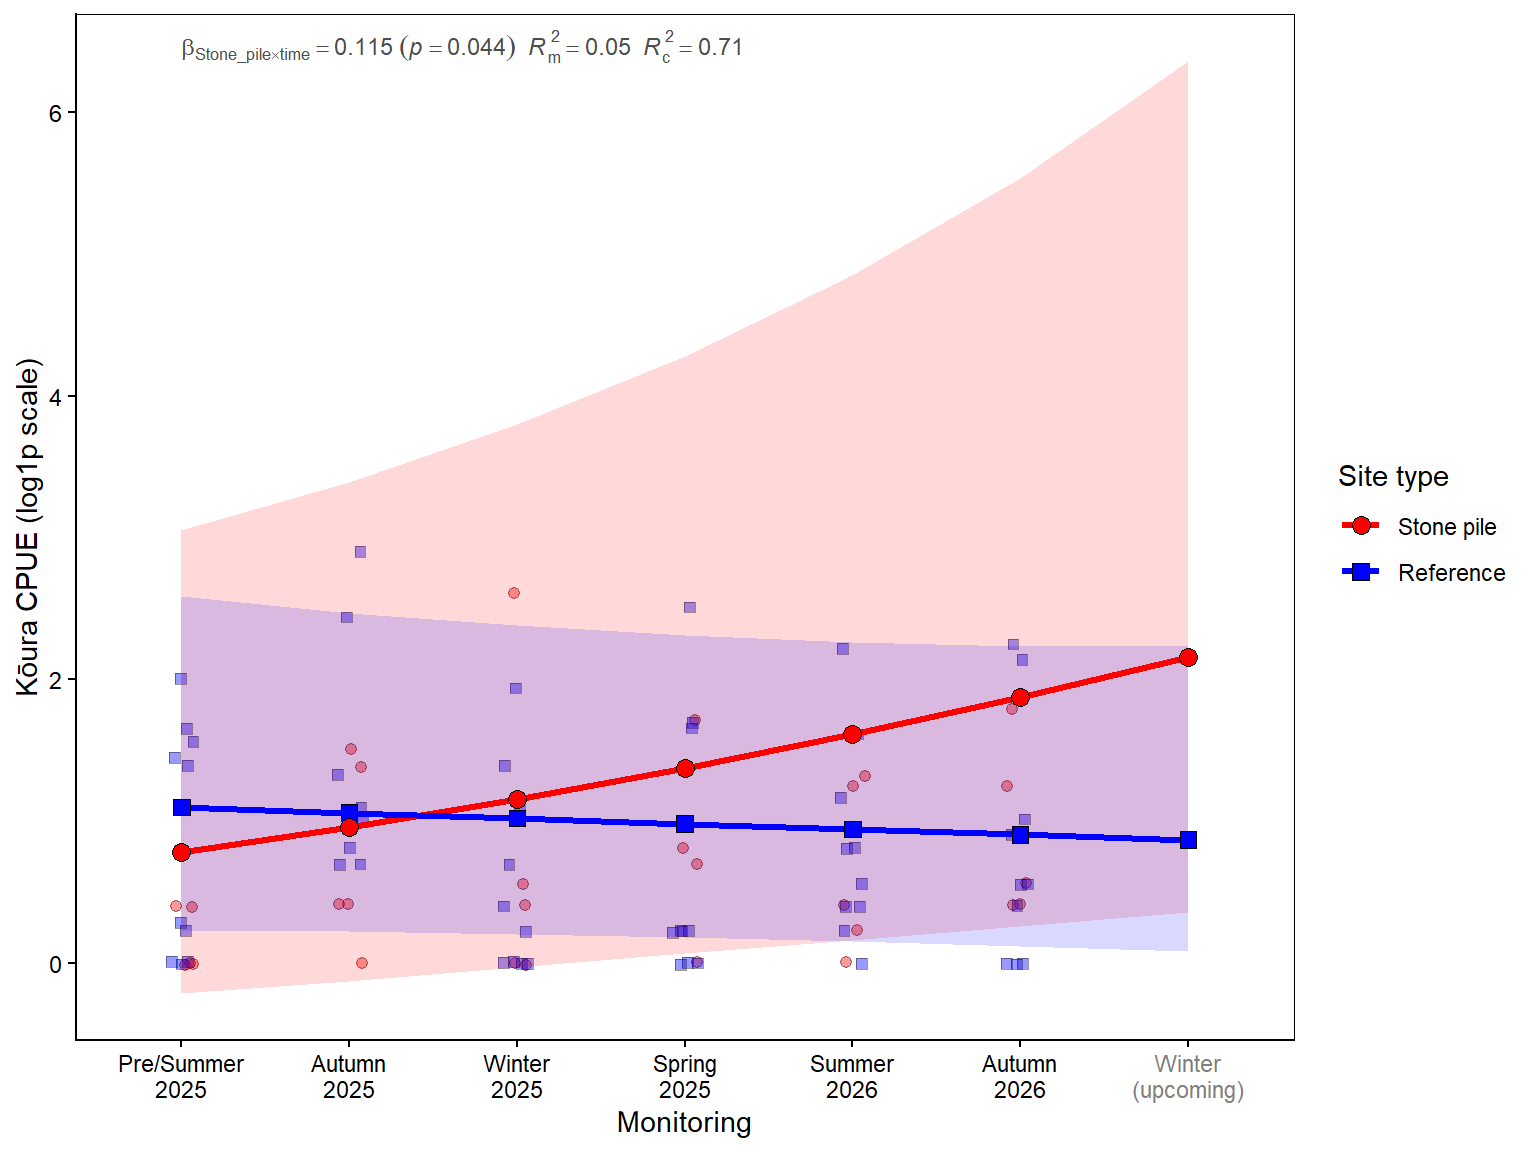

In [ ]:
#| 

# R² for the plot caption/results
r2_m3 <- MuMIn::r.squaredGLMM(m3_conv)

# Clean numeric values for annotation
beta_val <- round(fixef(m3_conv)["siteStone_pile:monitoring_int"], 3)
p_val    <- round(summary(m3_conv)$coefficients["siteStone_pile:monitoring_int", "Pr(>|t|)"], 3)
r2_vals  <- MuMIn::r.squaredGLMM(m3_conv)
r2m_val  <- round(r2_vals[1, "R2m"], 2)
r2c_val  <- round(r2_vals[1, "R2c"], 2)

# Use plotmath-safe expression — no special unicode characters
model_label <- paste0("italic(beta)[Stone_pile%*%time]==", beta_val, "~(italic(p)==", p_val, ")", "~~italic(R)[m]^2==", r2m_val, "~~italic(R)[c]^2==", r2c_val)

convergence_data_plot <- convergence_data %>%
  filter(!is.na(`Weighted_CPUE_Kōura`)) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

convergence_plot <- ggplot() +
  geom_point(data = convergence_data_plot, aes(monitoring_int, log1p(`Weighted_CPUE_Kōura`),  fill = site, shape = site),  colour = "black",  alpha = 0.4, size = 1.8, stroke = 0.5, position = position_jitter(width = 0.08, seed = 42),show.legend = FALSE) +
  geom_ribbon(data = emm_m3_df, aes(monitoring_int, response,  ymin = lower.CL, ymax = upper.CL, fill = site),  alpha = 0.15, colour = NA,  show.legend = FALSE) +
  geom_line(data = emm_m3_df,  aes(monitoring_int, response,  colour = site, group = site), linewidth = 1.1) +
  geom_point(data = emm_m3_df, aes(monitoring_int, response,  fill = site, shape = site), colour = "black", size = 3, stroke = 0.4) +
  annotate("text", x = 0, y = Inf, label = model_label, parse = TRUE,  hjust = 0, vjust = 1.4, size = 3.2, colour = "grey30") +
  scale_colour_manual(values = conv_colours, labels = conv_labels) +
  scale_fill_manual(  values = conv_fill,    labels = conv_labels) +
  scale_shape_manual( values = conv_shapes,  labels = conv_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(x= "Monitoring",y= "Kōura CPUE (log1p scale)",colour = "Site type",fill= "Site type",shape  = "Site type")+
  theme(axis.text.x = element_text(colour = c(rep("black", 6), "grey50")))


# Session info

In [ ]:
sessionInfo()


R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26100)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_New Zealand.utf8  LC_CTYPE=English_New Zealand.utf8   
[3] LC_MONETARY=English_New Zealand.utf8 LC_NUMERIC=C                        
[5] LC_TIME=English_New Zealand.utf8    

time zone: Pacific/Auckland
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] readxl_1.4.5        writexl_1.5.4       lubridate_1.9.5    
 [4] forcats_1.0.1       stringr_1.6.0       dplyr_1.2.0        
 [7] purrr_1.2.1         readr_2.2.0         tidyr_1.3.2        
[10] tibble_3.3.1        ggplot2_4.0.2       tidyverse_2.0.0    
[13] usethis_3.2.1       patchwork_1.3.2     lmerTest_3.2-1     
[16] lme4_1.1-38         Matrix_1.7-4        emmeans_2.0.2      
[19] broom.mixed_0.2.9.7 DHARMa_0.4.7        glmmTMB_1.1.14     


```` markdown
---
title: "Analysis Notebook"
format:
  html:
    fig-path: "analysis_files/figure-html/"
    theme:
      light: flatly
      dark: darkly
    code-fold: true
    code-tools: true
    code-summary: "View Code"
    toc: true
    toc-depth: 3
    number-sections: true
fig-width: 8
fig-height: 6

execute:
  freeze: false
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false

packages <- c("MuMIn","lunar", "glmmTMB", "DHARMa", "broom.mixed", "emmeans", "lmerTest", "lme4", "patchwork", "devtools", "tidyverse", "dplyr","writexl","readxl")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))
  }
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)
}

invisible(lapply(packages, quiet_load))

exc_file_dir  <- "data/raw/Data_Stone_piles_Rotoiti.xlsx"
raw_data_dir  <- "data/raw"
der_data_dir  <- "data/derived"
out_dir       <- "outputs"

# Read data
Site_info          <- readxl::read_excel(exc_file_dir, sheet = "Site_info")
Monitoring_data    <- readxl::read_excel(exc_file_dir, sheet = "Monitoring_data")
Chemical_data      <- readxl::read_excel(exc_file_dir, sheet = "Chemical_data")
Stone_pile_data    <- readxl::read_excel(exc_file_dir, sheet = "Stone_pile_data")  %>% select(-starts_with("..."))
Weed_data          <- readxl::read_excel(exc_file_dir, sheet = "Weed_data")  %>% select(-starts_with("..."))
Fish_data          <- readxl::read_excel(exc_file_dir, sheet = "Fish_data")  %>% select(-starts_with("..."))
Macroinvertebrates <- readxl::read_excel(exc_file_dir, sheet = "Macroinvertebrates")

base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "Arial", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)

site_colours <- c("Stone_pile" = "#ff0000", "Control" = "#eeff00", "Reference" = "#0000ff")
site_fill <- c("Stone_pile" = "#ff0000", "Control" = "#eeff00", "Reference" = "#0000ff")
site_shapes  <- c("Stone_pile" = 21,  "Control" = 24, "Reference" = 22)

conv_colours <- c("Stone_pile"= "#ff0000","Reference" = "#0000ff")
conv_fill    <- conv_colours
conv_shapes  <- c("Stone_pile" = 21,"Reference" = 22)

site_labels <- c("Stone_pile" = "Stone pile", "Control" = "Control", "Reference" = "Reference")
conv_labels <- c("Stone_pile" = "Stone pile", "Reference" = "Reference")


monitor_labels <- c("Pre/Summer\n2025", "Autumn\n2025", "Winter\n2025", "Spring\n2025", "Summer\n2026", "Autumn\n2026", "Winter\n(upcoming)")

```


# CPUE and BPUE derivation
## Length–weight model and predicted weights
quarto-executable-code-5450563D

```r
#| label: fig-length-weight
#| include: true
#| fig-cap: "."

# use size of koura to fill missing weights.
lw_model <- lm(log10(weight_g) ~ log10(length_mm), data = Fish_data, subset = species_name == "Freshwater_crayfish", na.action = na.exclude)

# extract the residual variance
sigma_log10 <- sigma(lw_model)
c <- 10^(0.5 * sigma_log10^2)

Fish_data <- Fish_data |>
  mutate(is_koura = species_name == "Freshwater_crayfish",
    Predicted_weight = case_when( !is.na(weight_g) ~ weight_g,
      is_koura ~ {pred_log <- predict(lw_model, newdata = pick(everything()))
        10^(pred_log) * c}, TRUE ~ NA_real_ ),
    Weight_source = case_when(is_koura & !is.na(weight_g) ~ "measured",
      is_koura & is.na(weight_g) ~ "predicted",TRUE ~ NA_character_))

count_df <- Fish_data |>
  dplyr::filter(is_koura, !is.na(Weight_source)) |>
  dplyr::count(Weight_source, name = "n")

measured_n  <- count_df$n[count_df$Weight_source == "measured"]
predicted_n <- count_df$n[count_df$Weight_source == "predicted"]

total_koura <- Fish_data |>
  dplyr::filter(is_koura) |>
  nrow()

hist(Fish_data |> dplyr::filter(is_koura) |> dplyr::pull(length_mm), xlab = "Length (mm)")

# Extract model coefficients
a <- coef(lw_model)[1]
b <- coef(lw_model)[2]

# Create formula text for the plot
formula_text <- paste0( "log10(Weight[g]) = ", round(a, 3), " + ", round(b, 3), " * log10(OCL Length[mm])")

# Plot with formula added
length_weight_plot <- ggplot(
Fish_data |> dplyr::filter(is_koura),
aes(x = length_mm, y = Predicted_weight, shape = Weight_source)) +
geom_point(size = 2.2, colour = "black", stroke = 0.6) +
scale_shape_manual(values = c("measured" = 16, "predicted" = 1)) +
labs(x = "OCL length (mm)", y = "Weight (g)", shape = "Weight source") +
annotate("text", x = Inf, y = Inf, label = formula_text, hjust = 1.1, vjust = 1.3, size = 3) 

ggsave(file.path(out_dir, "fig-length-weight.png"),length_weight_plot,width = 8, height = 5, dpi = 300)

length_weight_plot

```

## Build CPUE and BPUE tables
quarto-executable-code-5450563D

```r
#| label: cpue-bpue
#| include: false

CPUE_BPUE_legacy <- Fish_data %>%
  filter(!is.na(species)) %>%
  group_by(monitoring_id, species, net_type) %>%
  dplyr::reframe(
    Total_Individuals = sum(amount, na.rm = TRUE),
    Total_Weight      = sum(weight_g, na.rm = TRUE),
    Total_Effort      = dplyr::first(amount_nets),
    CPUE              = Total_Individuals / Total_Effort,
    BPUE              = Total_Weight      / Total_Effort,
    Mean_Length       = mean(length_mm, na.rm = TRUE),
    Min_Length        = ifelse(all(is.na(length_mm)), NA, min(length_mm, na.rm = TRUE)),
    Max_Length        = ifelse(all(is.na(length_mm)), NA, max(length_mm, na.rm = TRUE)),
    Mean_Weight       = mean(weight_g, na.rm = TRUE),
    Min_Weight        = ifelse(all(is.na(weight_g)), NA, min(weight_g, na.rm = TRUE)),
    Max_Weight        = ifelse(all(is.na(weight_g)), NA, max(weight_g, na.rm = TRUE))
  )

CPUE_BPUE_weighted <- CPUE_BPUE_legacy %>%
  group_by(monitoring_id, species) %>%
  summarise(
    Total_Individuals       = sum(Total_Individuals, na.rm = TRUE),
    Total_Weight            = sum(Total_Weight,      na.rm = TRUE),
    Weighted_CPUE_numerator = sum(CPUE * Total_Effort,  na.rm = TRUE),
    Weighted_BPUE_numerator = sum(BPUE * Total_Effort,  na.rm = TRUE),
    Total_Effort_sum        = sum(Total_Effort,         na.rm = TRUE),
    Mean_Length             = mean(Mean_Length, na.rm = TRUE),
    Min_Length              = ifelse(all(is.na(Min_Length)), NA, min(Min_Length, na.rm = TRUE)),
    Max_Length              = ifelse(all(is.na(Max_Length)), NA, max(Max_Length, na.rm = TRUE)),
    Mean_Weight             = mean(Mean_Weight, na.rm = TRUE),
    Min_Weight              = ifelse(all(is.na(Min_Weight)), NA, min(Min_Weight, na.rm = TRUE)),
    Max_Weight              = ifelse(all(is.na(Max_Weight)), NA, max(Max_Weight, na.rm = TRUE)),
    .groups = "drop") %>%
  ungroup() %>%
  mutate(Total_Effort_sum = ifelse(monitoring_id %in% c("16_0", "10_1", "3_2", "16_2"), 3, 4),
    Weighted_CPUE    = Weighted_CPUE_numerator / Total_Effort_sum,
    Weighted_BPUE    = Weighted_BPUE_numerator / Total_Effort_sum)

species_presence_absence <- Fish_data %>%
  filter(!is.na(species)) %>%
  distinct(monitoring_id, species) %>%
  mutate(presence = 1) %>%
  pivot_wider(
    names_from  = species,
    values_from = presence,
    values_fill = list(presence = 0),
    names_prefix = "Presence_") %>%
  mutate(Predator_Fish_Presence = pmax(Presence_Trout, Presence_Eel, Presence_Catfish))

CPUE_BPUE_weighted_summary <- CPUE_BPUE_weighted %>%
  pivot_wider(
    names_from  = species,
    values_from = c(
      Total_Individuals, Weighted_CPUE, Weighted_BPUE, Total_Weight,
      Mean_Length, Mean_Weight, Weighted_CPUE_numerator, Weighted_BPUE_numerator,
      Total_Effort_sum, Min_Length, Max_Length, Min_Weight, Max_Weight),
    names_sep   = "_", values_fill = list(Total_Individuals = 0, Weighted_CPUE = 0, Weighted_BPUE = 0)) %>%
  mutate(
    Richness  = rowSums(dplyr::select(., starts_with("Total_Individuals_")) > 0),
    Abundance = rowSums(dplyr::select(., starts_with("Total_Individuals_") & !ends_with(c("_Bullies", "_Common_smelt")))))
```


# Combined all datasets
quarto-executable-code-5450563D

```r
#| label: combine-data
#| include: true

unit_metadata <- dplyr::bind_rows(Monitoring_data %>%
    dplyr::select(parameter, unit), Chemical_data %>%
    dplyr::select(parameter, unit)) %>%
  dplyr::distinct() %>%
  dplyr::rename(Variable = parameter, Unit = unit)

Monitoring_summary <- Monitoring_data %>%
  dplyr::select(-group, -notes, -unit, -monitoring_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Riparian_vegetation, Vegetation_nearby, Overhanging_trees, Erosion, Structure, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter, Wood_cover ), ~ as.numeric(.)))

Chemical_summary <- Chemical_data %>%
  dplyr::select(-group, -notes, -unit, -site_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), ~ as.numeric(.)))

Weed_summary <- Weed_data %>%
  group_by(monitoring_id, weed_type, native_status) %>%
  summarise(Total_Cover = sum(percentage_cover, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from  = c(weed_type, native_status), values_from = Total_Cover, values_fill = 0) %>% 
  dplyr::select(monitoring_id, Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Turf_Native)

Stone_pile_summary <- Stone_pile_data %>%
  select(-unit, -notes, -site_id)%>%
  pivot_wider(names_from = c(parameter, stone_pile_id), values_from = value, names_sep = ".")

Macroinvertebrates_sum <- Macroinvertebrates %>%
  group_by(monitoring_id, species) %>%
  summarise(Total_amount = sum(amount, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = c(species), values_from = Total_amount, values_fill = 0) %>%
  mutate(Invertebrates_Richness  = rowSums(dplyr::select(., -monitoring_id) > 0),
    Invertebrates_Abundance = rowSums(dplyr::select(., -monitoring_id)))

Combined_data <- Site_info %>%
  left_join(Monitoring_summary, by = "site_id") %>%
  left_join(Chemical_summary, by = c("monitoring_id")) %>%
  left_join(Weed_summary, by = c("monitoring_id")) %>%
  left_join(Stone_pile_summary, by = c("monitoring_id")) %>%
  left_join(CPUE_BPUE_weighted_summary, by = "monitoring_id") %>%
  left_join(species_presence_absence, by = "monitoring_id") %>%
  left_join(Macroinvertebrates_sum, by = "monitoring_id")

Combined_data <- Combined_data %>%
  dplyr::mutate(Presence_rocks = dplyr::if_else(Cobble > 1 | Boulders > 1, 1, 0),
    Period = factor(dplyr::if_else(monitoring == 0, "Before", "After"),levels = c("Before", "After")),
    Date  = as.Date(date_time),
    Time  = format(date_time, "%H:%M:%S"),
    Year  = lubridate::year(date_time),
    Month = lubridate::month(date_time, label = TRUE),
    Day   = lubridate::day(date_time),
    Season = dplyr::case_when(
      Month %in% c("Dec", "Jan", "Feb") ~ "Summer",
      Month %in% c("Mar", "Apr", "May") ~ "Autumn",
      Month %in% c("Jun", "Jul", "Aug") ~ "Winter",
      Month %in% c("Sep", "Oct", "Nov") ~ "Spring",
      TRUE ~ NA_character_),
    Date_Time_Numeric = as.numeric(date_time),
    Monitoring_label = dplyr::case_when(
      monitoring == 0 ~ "0 Pre/Summer",
      monitoring == 1 ~ "1 Autumn",
      monitoring == 2 ~ "2 Winter",
      monitoring == 3 ~ "3 Spring",
      monitoring == 4 ~ "4 Summer",
      monitoring == 5 ~ "5 Autumn",
      monitoring == 6 ~ "6 Winter",
      TRUE ~ as.character(monitoring)
    ) %>% as.factor(), site_id = as.factor(site_id)) %>%
  dplyr::mutate(Depth_5m  = suppressWarnings(as.numeric(Distance_5m)), Depth_20m = suppressWarnings(as.numeric(Distance_20m)),
    Slope_0_5m  = Depth_5m  / 5, Slope_0_20m = Depth_20m / 20)
        

habitat_classification <- Combined_data %>%
  dplyr::select(site_id, DHT, lake,
                Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover) %>%
  pivot_longer(cols = c(Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                  Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover),
    names_to  = "Type", values_to = "Percentage") %>%
  group_by(site_id) %>%
  summarise(Rocky_Percentage  = sum(Percentage[Type %in% c("Bedrock", "Boulders", "Cobble")], na.rm = TRUE),
    Sand_Percentage     = sum(Percentage[Type == "Sand"], na.rm = TRUE),
    Mud_Percentage      = sum(Percentage[Type %in% c("Mud", "Organic_matter")], na.rm = TRUE),
    Emergent_Percentage = sum(Percentage[Type %in% c("Emergent_Native")], na.rm = TRUE),
    Substrate_index = sum(
      0.08 * Percentage[Type == "Bedrock"] +
      0.07 * Percentage[Type == "Boulders"] +
      0.06 * Percentage[Type == "Cobble"] +
      0.04 * Percentage[Type == "Gravel"] +
      0.03 * Percentage[Type == "Sand"] +
      0.02 * Percentage[Type == "Organic_matter"] +
      0.01 * Percentage[Type == "Mud"],
      na.rm = TRUE),.groups = "drop") %>%
  mutate(Habitat_Type = case_when(
      Rocky_Percentage    > 25 ~ "Rocky",
      Emergent_Percentage > 25 ~ "Emergent Macrophyte",
      Sand_Percentage   >= Mud_Percentage ~ "Sandy",
      TRUE ~ "Muddy")) %>%
  dplyr::select(site_id, Habitat_Type, Substrate_index)

Combined_data <- Combined_data %>%
  left_join(habitat_classification, by = c("site_id"))%>%
  dplyr::mutate(monitoring_int = as.integer(monitoring),
    pair_id = factor(ceiling(as.numeric(as.character(site_id)) / 2)),
    koura_present = as.integer(`Total_Individuals_Kōura` > 0))

Combined_data <- Combined_data %>%
  mutate(lunar_phase = lunar.phase(Date, name = FALSE),  # 0-2π radians
    lunar_illumination = (1 - cos(lunar.phase(Date))) / 2,  # 0=new, 1=full
    lunar_name = lunar.phase(Date, name = TRUE))     # "New", "Waxing", "Full", "Waning"

# Monitoring quality flag — based on known compromised events
compromised_ids <- c("6_1", "13_1", "14_1", "1_2", "2_2", "19_2", "20_2", "1_3", "2_3", "6_5")

Combined_data <- Combined_data %>%
  mutate(monitoring_quality = case_when(monitoring_id %in% compromised_ids ~ "compromised", is.na(`Total_Individuals_Kōura`) ~ "missing", TRUE  ~ "complete"))

writexl::write_xlsx(Combined_data, file.path(der_data_dir, "Combined_data.xlsx"))
write.csv(Combined_data, file.path(der_data_dir, "Combined_data.csv"), row.names = FALSE)
write.csv(habitat_classification, file.path(der_data_dir, "habitat_classification.csv"), row.names = FALSE)

all_data <- Combined_data

```

## Fish summary table 
quarto-executable-code-5450563D

```r
#| label: tbl-fish-summary
#| include: true
#| tbl-cap: "."

# Create a summary table for fish counts by site and monitoring
fish_summary <- all_data %>%
  select(site_id, Monitoring_label,
         Total_Individuals_Kōura,
         Total_Individuals_Bullies,
         Total_Individuals_Common_smelt,
         Total_Individuals_Goldfish,
         Total_Individuals_Eel,
         Total_Individuals_Kōaro,
         Total_Individuals_Catfish,
         Total_Individuals_Trout,
         Total_Individuals_Mosquitofish) %>%
  pivot_longer(
    cols = c(Total_Individuals_Kōura, Total_Individuals_Bullies,
             Total_Individuals_Common_smelt, Total_Individuals_Goldfish,
             Total_Individuals_Eel, Total_Individuals_Kōaro,
             Total_Individuals_Catfish, Total_Individuals_Trout,
             Total_Individuals_Mosquitofish),
    names_to = "Species",
    values_to = "Count") %>%
  group_by(site_id, Monitoring_label, Species) %>%
  summarise(Total_Count = sum(Count, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(
    names_from = Species,
    values_from = Total_Count) %>%
  arrange(site_id, Monitoring_label, Total_Individuals_Kōura, Total_Individuals_Bullies, Total_Individuals_Common_smelt,    Total_Individuals_Goldfish, Total_Individuals_Eel,Total_Individuals_Kōaro,Total_Individuals_Catfish,Total_Individuals_Trout,Total_Individuals_Mosquitofish)


write.csv(fish_summary, file.path(der_data_dir, "tbl-fish-summary.csv"), row.names = FALSE)

fish_summary

```


# Environmental and fish summaries (table)
quarto-executable-code-5450563D

```r
#| label: tbl-env-fish-summary
#| tbl-cap: Distribution of environmental and biotic variables measured at sampling sites. Summaries are grouped by site (ID) across repeated sampling events; an overall ‘All sites’ summary is also provided

group_var <- "site_id" # or monitoring_id

var_order_exact <- c("Substrate index","Riparian vegetation","Overhanging trees","Wood cover","Emergent vegetation","Submerged vegetation", "Temperature","Dissolved oxygen","Specific conductivity","pH","Presence Kōura", "Presence Catfish","Presence Eel","Presence Goldfish","Presence Common smelt", "Presence Kōaro","Presence Trout")

ci95 <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  if (n < 2) return(c(NA_real_, NA_real_))
  se <- stats::sd(x) / sqrt(n)
  tcrit <- stats::qt(0.975, df = n - 1)
  m <- mean(x)
  c(m - tcrit * se, m + tcrit * se)
}

site_lookup <- all_data %>%
  dplyr::select(site_id, site) %>%
  dplyr::distinct() %>%
  dplyr::mutate(site_id   = as.character(site_id), site = as.character(site))

unit_map <- dplyr::tibble(Variable = c("Substrate_index","Riparian_vegetation","Overhanging_trees","Wood_cover", "Temperature","DO_mgl","Specific_conductivity","pH"))

Env_data <- all_data %>%
  dplyr::mutate(
    Emergent_vegetation  = Emergent_Native + Emergent_Non_Native,
    Submerged_vegetation = Submerged_Non_Native) %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Substrate_index, Riparian_vegetation, Overhanging_trees, Wood_cover,
    Emergent_vegetation, Submerged_vegetation,
    Temperature, DO_mgl, Specific_conductivity, pH ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Value")

Env_summary_by_group <- Env_data %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_all <- Env_data %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_table <- dplyr::bind_rows(Env_summary_by_group, Env_summary_all)

# ---- Fish presence data (long) ----
Fish_data_long <- all_data %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Presence_Kōura, Presence_Catfish, Presence_Eel, Presence_Goldfish, Presence_Common_smelt, Presence_Kōaro, Presence_Trout ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Presence")

Fish_summary_by_group <- Fish_data_long %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_all <- Fish_data_long %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_table <- dplyr::bind_rows(Fish_summary_by_group, Fish_summary_all)

# ---- Combine + attach units + pretty variable names + exact ordering ----
EnvBio_summary_table <- dplyr::bind_rows(Env_summary_table, Fish_summary_table) %>%
  dplyr::mutate(Group = as.character(Group)) %>%
  dplyr::left_join(
    site_lookup,
    by = c("Group" = "site_id")) %>%
  dplyr::left_join(unit_metadata, by = "Variable") %>%
  dplyr::mutate(
    Variable = dplyr::recode(
      Variable,
      Substrate_index       = "Substrate index",
      Riparian_vegetation   = "Riparian vegetation",
      Overhanging_trees     = "Overhanging trees",
      Wood_cover            = "Wood cover",
      Emergent_vegetation   = "Emergent vegetation",
      Submerged_vegetation  = "Submerged vegetation",
      Temperature           = "Temperature",
      DO_mgl                = "Dissolved oxygen",
      Specific_conductivity = "Specific conductivity",
      pH                    = "pH",
      Presence_Kōura        = "Presence Kōura",
      Presence_Catfish      = "Presence Catfish",
      Presence_Eel          = "Presence Eel",
      Presence_Goldfish     = "Presence Goldfish",
      Presence_Common_smelt = "Presence Common smelt",
      Presence_Kōaro        = "Presence Kōaro",
      Presence_Trout        = "Presence Trout" ),
    Unit = dplyr::coalesce(Unit, "")) %>%
  dplyr::mutate(
    Variable = factor(as.character(Variable), levels = var_order_exact),
    Group    = as.character(Group)) %>%
  dplyr::select(Group, Variable, Unit, n, Mean, Median, Min, Max, CI_low, CI_high) %>%
  dplyr::arrange(Variable, dplyr::desc(Group == "All sites"), Group)

# Optional: if you want Group sorted numerically when Group is ID
if (group_var == "site_id") {
  EnvBio_summary_table <- EnvBio_summary_table %>%
    dplyr::mutate(
      Group_num = suppressWarnings(as.numeric(Group))
    ) %>%
    dplyr::arrange(
      Variable,
      dplyr::desc(Group == "All sites"),
      Group_num,
      Group
    ) %>%
    dplyr::select(-Group_num)
}

write.csv(EnvBio_summary_table, file = file.path(out_dir, "EnvBio_summary_table.csv"), row.names = FALSE)

knitr::kable(EnvBio_summary_table, digits = 2, align = c("l","l","l","r","r","r","r","r","r","r"))

```

# Diagnose the monitoring data
quarto-executable-code-5450563D

```r
# Diagnose the pattern first
missing_table <- all_data %>%
  filter(monitoring_quality != "complete") %>%
  select(site_id, site, Monitoring_label, monitoring_id, monitoring_quality) %>%
  arrange(site_id, Monitoring_label)


```

# Kōura abundance plot
quarto-executable-code-5450563D

```r
#| label: fig-koura-abundance
#| include: true
#| fig-cap: "Kōura abundance plot."

koura_plot1 <- all_data %>%
   dplyr::filter(site != "Reference") %>%
    ggplot(aes(Monitoring_label, `Total_Individuals_Kōura`, shape = site, fill = site)) +
    geom_point(size = 2, col = "black") +
    geom_smooth(se = FALSE, aes(group = site, col = site)) +
    facet_wrap(~site_id, ncol=2, scales = "free_y") +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    labs(y = "Total Kōura", x = "Monitoring") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

koura_plot2 <- all_data %>%
  dplyr::filter(site == "Reference") %>%
    ggplot(aes(Monitoring_label, `Total_Individuals_Kōura`, shape = site, , fill = site)) +
    geom_point(size = 2, col = "black") +
    geom_smooth(se = FALSE, aes(group = site, col = site)) +
    facet_wrap(~site_id, ncol=2, scales = "free_y") +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    labs(y = "Total Kōura", x = "Monitoring") +
    theme(axis.title.y = element_blank()) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
 
combined_koura <- koura_plot1 + koura_plot2 + plot_layout(guides = "collect") & theme(legend.position = "bottom")

ggsave(file.path(out_dir, "fig-koura-abundance.png"), combined_koura, width = 400, height = 250, units = "mm", dpi = 300)

combined_koura
```


# Kōura trend plot
quarto-executable-code-5450563D

```r
#| label: fig-koura-trends
#| include: true
#| fig-cap: "Mean kōura catch per unit effort (± 95% CI) across monitoring rounds by site type. Points are means across sites within each site type; error bars show 95% confidence intervals."

koura_summary <- all_data %>%
  group_by(Monitoring_label, monitoring_int, site) %>%
  summarise(
    mean_cpue = mean(Weighted_CPUE_Kōura, na.rm = TRUE),
    se        = sd(Weighted_CPUE_Kōura, na.rm = TRUE) / sqrt(sum(!is.na(Weighted_CPUE_Kōura))),
    n         = sum(!is.na(Weighted_CPUE_Kōura)),
    ci95      = qt(0.975, df = pmax(n - 1, 1)) * se,
    .groups   = "drop") %>%
  mutate(
    site    = factor(site, levels = c("Stone_pile", "Control", "Reference")),
    ci_low  = pmax(mean_cpue - ci95, 0),
    ci_high = mean_cpue + ci95)

koura_trends <- ggplot(koura_summary, aes(monitoring_int , mean_cpue, shape = site, fill = site)) +
  geom_errorbar(aes(ymin = ci_low, ymax = ci_high), position = position_dodge(width = 0.4), width = 0.35, colour = "grey40") +
  geom_line(aes(group = site, col = site), position = position_dodge(width = 0.4), linewidth = 0.6) +
  geom_point(size = 3, stroke = 0.4, position = position_dodge(width = 0.4)) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(values = site_fill, labels = site_labels) +
  scale_shape_manual(values = site_shapes, labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(y = expression("Mean kōura CPUE (± 95% CI)"), x  = "Monitoring", col = "Site type", shape  = "Site type", fill = "Site type") +
  theme(axis.text.x = element_text(colour = c(rep("black", 6), "grey50")))

ggsave(file.path(out_dir, "fig-koura-trends.png"), koura_trends, width = 8, height = 4, dpi = 300)

koura_trends


```

# Fish abundance
quarto-executable-code-5450563D

```r
#| label: Fish abundance plots
#| fig-cap: "."

species_vec <- c("Kōura", "Catfish", "Kōaro", "Goldfish")

make_metrics <- function(species) {
  cols <- c(
    paste0("Total_Individuals_", species),
    paste0("Weighted_CPUE_", species),
    paste0("Weighted_BPUE_", species))

  labels <- c(
    paste("Total", species),
    "Weighted CPUE",
    "Weighted BPUE")

  stats::setNames(labels, cols)
}

plots_by_species <- vector("list", length(species_vec))
names(plots_by_species) <- species_vec

for (sp in species_vec) {

  metrics_to_plot <- make_metrics(sp)

  metric_cols <- names(metrics_to_plot)
  metric_cols <- metric_cols[metric_cols %in% names(all_data)]
  if (length(metric_cols) == 0) next

  plot_data <- all_data %>%
    dplyr::mutate(monitoring_int = factor(monitoring_int)) %>%
    tidyr::pivot_longer( cols = dplyr::all_of(metric_cols),  names_to  = "Metric", values_to = "Value") %>%
    dplyr::mutate(Metric = factor(Metric, levels = metric_cols,  labels = unname(metrics_to_plot[metric_cols])))

  p_nonref <- plot_data %>%
    dplyr::filter(site != "Reference") %>%
    ggplot(aes(monitoring_int, Value, col = site)) +
    geom_point(size = 2) +
    geom_smooth(se = FALSE, aes(group = site)) +
    facet_grid(Metric ~ site_id, scales = "free_y") +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(  values = site_colours, labels = site_labels) +
    labs(x = NULL, y = NULL) +
    theme(axis.text.x = element_blank())

  p_ref <- plot_data %>%
    dplyr::filter(site == "Reference") %>%
    ggplot(aes(monitoring_int, Value, col = site)) +
    geom_point(size = 2) +
    geom_smooth(se = FALSE, aes(group = site)) +
    facet_grid(Metric ~ site_id, scales = "free_y") +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(  values = site_colours, labels = site_labels) +
    labs(x = "Monitoring", y = NULL) +
    theme(axis.title.y = element_blank()) +
    theme(axis.text.x = element_text(hjust = 1))

  combined_plot <- p_nonref + p_ref +
    patchwork::plot_layout(guides = "collect", ncol = 1) &
    theme(legend.position = "bottom")

  out_name <- paste0(sp, "_plots.png")

  ggsave(
    filename = file.path(out_dir, out_name),
    plot     = combined_plot,
    width    = 400,
    height   = 250,
    units    = "mm",
    dpi      = 300
  )

  plots_by_species[[sp]] <- combined_plot
}

plots_by_species[["Kōura"]]

```

# Fish trends
quarto-executable-code-5450563D

```r
#| label: species-trends
#| fig-width: 14
#| fig-height: 16
#| dpi: 300
#| fig-cap: "Mean catch per monitoring round (± 95% CI) by site type for all monitored species."

# Species to plot and their display names
species_vec_trends <- c("Kōura", "Catfish", "Kōaro", "Goldfish")

species_labels <- c("Kōura"= "Kōura","Catfish"= "Catfish", "Kōaro"= "Kōaro","Goldfish"= "Goldfish")

# Function to build one trend plot per species
make_trend_plot <- function(sp) {

  col_name <- paste0("Total_Individuals_", sp)
  if (!col_name %in% names(all_data)) return(NULL)

  summary_df <- all_data %>%
    group_by(monitoring_int, site) %>%
    summarise(
      mean_n = mean(.data[[col_name]], na.rm = TRUE),
      se     = sd(.data[[col_name]], na.rm = TRUE) /
               sqrt(sum(!is.na(.data[[col_name]]))),
      n      = sum(!is.na(.data[[col_name]])),
      ci95   = qt(0.975, df = pmax(n - 1, 1)) * se,
      .groups = "drop") %>%
    mutate(
      site   = factor(site, levels = c("Stone_pile", "Control", "Reference")),
      ci_low  = pmax(mean_n - ci95, 0),
      ci_high = mean_n + ci95)

  ggplot(summary_df,
      aes(monitoring_int, mean_n,
          colour = site, shape = site, fill = site)) +
    geom_errorbar(aes(ymin = ci_low, ymax = ci_high),
                  position = position_dodge(width = 0.4),
                  width = 0.25, linewidth = 0.4, colour = "grey40") +
    geom_line(aes(group = site),
              position = position_dodge(width = 0.4),
              linewidth = 0.6) +
    geom_point(size = 2.5, stroke = 0.4,
               position = position_dodge(width = 0.4)) +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    scale_x_continuous(
      breaks = 0:6,
      labels = monitor_labels,
      limits = c(-0.3, 6.3)) +
    labs(
      title  = species_labels[[sp]],
      x      = NULL,
      y      = "Mean caught (± 95% CI)",
      colour = "Site type",
      shape  = "Site type",
      fill   = "Site type") +
    theme(
      axis.text.x     = element_text(size = 7,
        colour = c(rep("black", 6), "grey50")),
      axis.text.y     = element_text(size = 8),
      axis.title.y    = element_text(size = 9),
      plot.title      = element_text(size = 10, face = "bold"),
      legend.position = "none")   # collect legend from patchwork
}

# Generate all plots, drop NULLs
trend_plots <- purrr::map(species_vec_trends, make_trend_plot) %>%
  purrr::set_names(species_vec_trends) %>%
  purrr::compact()

combined_trends <- patchwork::wrap_plots(trend_plots, ncol = 2) +
  patchwork::plot_layout(guides = "collect") +
  patchwork::plot_annotation(theme= theme(legend.position = "bottom")) & theme(legend.position = "bottom")

combined_trends

# Save combined
ggsave(file.path(out_dir, "fig-all-species-trends.png"), combined_trends, width  = 14, height = 8, units  = "in", dpi = 300)

# Also save individual plots if needed
#purrr::iwalk(trend_plots, ~ ggsave(filename = file.path(out_dir, paste0("fig-trend-", .y, ".png")), plot= .x, width= 8, height = 4, units = "in", dpi = 300))

```

# Chemical & Habitat Plot
quarto-executable-code-5450563D

```r
#| label: Chemical & Habitat Plot
#| fig-cap: "."

Chemical_data2 <- all_data %>%
  dplyr::select(monitoring_id, site_id, site, Monitoring_label, Habitat_Type, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH, Temperature) %>%
  tidyr::pivot_longer(cols = c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), names_to = "Variable", values_to = "Values") 

Chemical_plot <- ggplot(Chemical_data2, aes(Monitoring_label, Values, col = site_id)) +
  geom_point() +
  geom_smooth(se = FALSE, aes(group = site_id)) +
  facet_wrap(~ Variable, scales = "free", nrow = 2) +
  labs(y = "Value", x = "Monitoring") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#ggsave(file.path(out_dir, "Chemical_plot.png"), Chemical_plot, width = 10, height = 8,  dpi = 300)

Chemical_plot

Habitat_data <- all_data %>%
  dplyr::select(site_id, site, Habitat_Type,Slope_0_5m, Slope_0_20m, Substrate_index, Riparian_vegetation, Overhanging_trees, Wood_cover) %>%
  tidyr::pivot_longer(cols = c(Slope_0_5m, Slope_0_20m, Substrate_index, Riparian_vegetation, Overhanging_trees, Wood_cover), names_to  = "Variable", values_to = "Value") %>%
  dplyr::group_by(site_id, site, Variable) %>%
  dplyr::summarise(Value = dplyr::first(Value),.groups = "drop")

Habitat_plot <- ggplot(Habitat_data, aes(site_id, Value, fill = site)) +
  geom_col(col= "black") +
  facet_wrap(~ Variable, scales = "free", nrow = 2) +
  scale_fill_manual(values = site_fill, labels = site_labels) +
  labs(y = "Value", x = "Monitoring")

Habitat_plot

```



# BACI
quarto-executable-code-5450563D

```r
#| label: BACI

baci_koura_cpue <- lmer(Weighted_CPUE_Kōura ~ Period * site + Temperature + Substrate_index + (1 | site_id), data = all_data)

summary(baci_koura_cpue)
anova(baci_koura_cpue)

par(mfrow = c(2, 2))
plot(baci_koura_cpue)
pairs(emmeans(baci_koura_cpue, ~ site | Period))


baci_catfish_cpue <- lmer(log1p(Weighted_CPUE_Catfish) ~ Period * site + Temperature + Substrate_index + (1 | site_id), data = all_data)
summary(baci_catfish_cpue)
anova(baci_catfish_cpue)

```

# BACI models
quarto-executable-code-5450563D

```r
# KŌURA ANALYTICAL FRAMEWORK
# Three-model approach:
#   Model 1 — BACI CPUE (Stone_pile vs Control, log-transformed continuous)
#   Model 2 — BACI Occupancy (Stone_pile vs Control, binomial GLMM)
#   Model 3 — Convergence (Stone_pile vs Reference, temporal trajectory)


baci_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Control")) %>%
  mutate(Period = factor(Period, levels = c("Before", "After")), site = factor(site, levels = c("Control", "Stone_pile")), site_id = factor(site_id))

convergence_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Reference")) %>%
  mutate(site = factor(site, levels = c("Reference", "Stone_pile")), site_id = factor(site_id))


# MODEL 1 — BACI: CPUE (continuous, log-transformed)
# Fixed:  Period * site + monitoring_int + Temperature + Substrate_index
# Random: (1 | pair_id / site_id)   — sites nested in Stone_pile–control pairs


m1_cpue <- lmerTest::lmer(
  log1p(`Weighted_CPUE_Kōura`) ~
    Period * site +
    monitoring_int +
    Temperature +
    Substrate_index +
    (1 | pair_id / site_id),
  data    = baci_data,
  REML    = TRUE,
  control = lmerControl(optimizer = "bobyqa")
)

summary(m1_cpue)
anova(m1_cpue, type = "III")   # Type III for interaction term

# ── Estimated marginal means — the BACI contrasts ───
emm_m1 <- emmeans(m1_cpue, ~ site | Period)
pairs(emm_m1)                  # Stone_pile vs Control within Before / After

# Interaction contrast: (Stone_pile_After – Stone_pile_Before) – (Control_After – Control_Before)
contrast(emmeans(m1_cpue, ~ Period * site),
         interaction = c("consec", "pairwise"))

# ── Residual diagnostics ───────────────
sim_m1 <- simulateResiduals(m1_cpue, plot = TRUE)   # DHARMa
testDispersion(sim_m1)


# MODEL 2 — BACI: OCCUPANCY (binomial GLMM)
# Same fixed structure, binomial family
# glmmTMB gives more reliable convergence than glmer for this structure

m2_occ <- glmmTMB::glmmTMB(
  koura_present ~
    Period * site +
    monitoring_int +
    Temperature +
    Substrate_index +
    (1 | pair_id / site_id),
  data   = baci_data,
  family = binomial(link = "logit")
)

summary(m2_occ)
car::Anova(m2_occ, type = "III")   

# ── Marginal means on probability scale 
emm_m2 <- emmeans(m2_occ, ~ site | Period, type = "response")
pairs(emm_m2, adjust = "tukey")

# BACI interaction contrast (odds-ratio scale)
contrast(emmeans(m2_occ, ~ Period * site, type = "response"),
         interaction = c("consec", "pairwise"))

# ── Diagnostics 
sim_m2 <- simulateResiduals(m2_occ, plot = TRUE)
testDispersion(sim_m2)



# MODEL 3 — CONVERGENCE: Are constructed Stone_piles approaching reference state?
# Fixed:  site * monitoring_int + Temperature + Substrate_index
# Random: (1 | site_id)
# Interpretation: significant site:monitoring_int interaction where the gap
# narrows over time = convergence towards reference Stone_pile conditions
m3_conv <- lmerTest::lmer(log1p(`Weighted_CPUE_Kōura`) ~ site * monitoring_int + Temperature + Substrate_index + (1 | site_id), data = convergence_data, REML = TRUE, control = lmerControl(optimizer = "bobyqa"))

summary(m3_conv)
anova(m3_conv, type = "III")

# Predicted trajectories at each monitoring round 
emm_m3 <- emmeans(m3_conv,
  ~ site | monitoring_int,
  at      = list(monitoring_int = 0:6),
  type    = "response")

emm_m3_df <- as.data.frame(emm_m3)%>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

names(emm_m3_df)



# ── Pairwise gap at each monitoring round ────────────
# Tests whether Stone_pile EMM differs from Reference at each time point
pairs(emm_m3, reverse = TRUE) %>%
  as.data.frame() %>%
  arrange(monitoring_int) %>%
  print()


# m4
m4_size <- lmerTest::lmer(
  Mean_Length_Kōura ~ site * monitoring_int +
    (1 | site_id),
  data = all_data %>% filter(!is.na(Mean_Length_Kōura)))

summary(m4_size)


# m5
m5_quad <- lmerTest::lmer(
  log1p(`Weighted_CPUE_Kōura`) ~
    site * poly(monitoring_int, 2) +
    Temperature + Substrate_index +
    (1 | site_id),
  data = convergence_data)

anova(m3_conv, m5_quad)

# m6 Predator effect
m6a <- update(m3_conv, . ~ . + Presence_Catfish)
summary(m6a)

m6b <- update(m3_conv, . ~ . + Predator_Fish_Presence)
summary(m6b)

m6c <- update(m3_conv, . ~ . + Weighted_CPUE_Catfish)
summary(m6c)

m6d <- update(m3_conv, . ~ . + Weighted_CPUE_Catfish + Weighted_CPUE_Eel + Weighted_CPUE_Trout)
summary(m6d)

AIC(m3_conv, m6a, m6b, m6c, m6d)

convergence_data <- convergence_data %>%
  mutate(
    log_cpue_catfish = log1p(Weighted_CPUE_Catfish),
    log_cpue_eel     = log1p(Weighted_CPUE_Eel),
    log_cpue_trout   = log1p(Weighted_CPUE_Trout)
  )

m6c <- update(m3_conv, . ~ . + log_cpue_catfish)
m6d <- update(m3_conv, . ~ . + log_cpue_catfish + log_cpue_eel + log_cpue_trout)


# m7 Within Stone_pile sites only
m7_habitat <- lmerTest::lmer(
  log1p(`Weighted_CPUE_Kōura`) ~
    monitoring_int * Substrate_index +
    Temperature +
    (1 | site_id),
  data = all_data %>% filter(site == "Stone_pile"))

summary(m7_habitat)

all_data %>%
  filter(site == "Stone_pile") %>%
  ggplot(aes(monitoring_int, log1p(`Weighted_CPUE_Kōura`),
             colour = Substrate_index, group = site_id)) +
  geom_line() +
  geom_point() +
  scale_colour_viridis_c() +
  labs(title = "Individual Stone pile trajectories by substrate quality")

# m8
m8_conv <- lmerTest::lmer(log1p(`Weighted_BPUE_Kōura`) ~ site * monitoring_int + Temperature + Substrate_index + (1 | site_id), data = convergence_data, REML = TRUE, control = lmerControl(optimizer = "bobyqa"))

summary(m8_conv)
anova(m8_conv, type = "III")

# m9 lunar
m9_lunar <- update(m3_conv, . ~ . + lunar_illumination)
summary(m9_lunar)
AIC(m3_conv, m9_lunar)


# SUMMARY TABLE — effect sizes for all three models
# Sensitivity: complete observations only
m1_sens <- update(m1_cpue,
  data = baci_data %>% filter(monitoring_quality == "complete"))
m3_sens <- update(m3_conv,
  data = convergence_data %>% filter(monitoring_quality == "complete"))

# Compare key coefficients
broom.mixed::tidy(m1_sens, effects = "fixed") %>%
  filter(term == "PeriodAfter:siteStone_pile") %>%
  select(term, estimate, std.error, p.value)

broom.mixed::tidy(m3_sens, effects = "fixed") %>%
  filter(term == "siteStone_pile:monitoring_int") %>%
  select(term, estimate, std.error, p.value)


tidy_m1 <- broom.mixed::tidy(m1_cpue, conf.int = TRUE) %>%
  mutate(model = "M1 CPUE (lmer)")

tidy_m2 <- broom.mixed::tidy(m2_occ,  conf.int = TRUE) %>%
  mutate(model = "M2 Occupancy (glmmTMB)")

tidy_m3 <- broom.mixed::tidy(m3_conv, conf.int = TRUE) %>%
  mutate(model = "M3 Convergence (lmer)")

model_summary_table <- bind_rows(tidy_m1, tidy_m2, tidy_m3) %>%
  filter(effect == "fixed") %>%
  select(model, term, estimate, std.error, statistic, p.value, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), ~ round(.x, 4)))

print(model_summary_table)
write.csv(model_summary_table, file.path(out_dir, "model_summary_table.csv"), row.names = FALSE)
```


# fig-linear-model3
quarto-executable-code-5450563D

```r
#| label: fig-linear-model3
#| 

# R² for the plot caption/results
r2_m3 <- MuMIn::r.squaredGLMM(m3_conv)

# Clean numeric values for annotation
beta_val <- round(fixef(m3_conv)["siteStone_pile:monitoring_int"], 3)
p_val    <- round(summary(m3_conv)$coefficients["siteStone_pile:monitoring_int", "Pr(>|t|)"], 3)
r2_vals  <- MuMIn::r.squaredGLMM(m3_conv)
r2m_val  <- round(r2_vals[1, "R2m"], 2)
r2c_val  <- round(r2_vals[1, "R2c"], 2)

# Use plotmath-safe expression — no special unicode characters
model_label <- paste0("italic(beta)[Stone_pile%*%time]==", beta_val, "~(italic(p)==", p_val, ")", "~~italic(R)[m]^2==", r2m_val, "~~italic(R)[c]^2==", r2c_val)

convergence_data_plot <- convergence_data %>%
  filter(!is.na(`Weighted_CPUE_Kōura`)) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

convergence_plot <- ggplot() +
  geom_point(data = convergence_data_plot, aes(monitoring_int, log1p(`Weighted_CPUE_Kōura`),  fill = site, shape = site),  colour = "black",  alpha = 0.4, size = 1.8, stroke = 0.5, position = position_jitter(width = 0.08, seed = 42),show.legend = FALSE) +
  geom_ribbon(data = emm_m3_df, aes(monitoring_int, response,  ymin = lower.CL, ymax = upper.CL, fill = site),  alpha = 0.15, colour = NA,  show.legend = FALSE) +
  geom_line(data = emm_m3_df,  aes(monitoring_int, response,  colour = site, group = site), linewidth = 1.1) +
  geom_point(data = emm_m3_df, aes(monitoring_int, response,  fill = site, shape = site), colour = "black", size = 3, stroke = 0.4) +
  annotate("text", x = 0, y = Inf, label = model_label, parse = TRUE,  hjust = 0, vjust = 1.4, size = 3.2, colour = "grey30") +
  scale_colour_manual(values = conv_colours, labels = conv_labels) +
  scale_fill_manual(  values = conv_fill,    labels = conv_labels) +
  scale_shape_manual( values = conv_shapes,  labels = conv_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(x= "Monitoring",y= "Kōura CPUE (log1p scale)",colour = "Site type",fill= "Site type",shape  = "Site type")+
  theme(axis.text.x = element_text(colour = c(rep("black", 6), "grey50")))

ggsave(file.path(out_dir, "convergence_plot_m3.png"), convergence_plot, width = 8, height = 4, dpi = 300)

convergence_plot

```


# Session info
quarto-executable-code-5450563D

```r
#| label: session-info
#| include: true
#| code-fold: true
sessionInfo()
```
````